Mounted at /content/drive
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 14.6 MB/s eta 0:00:00
⚠️ Missing: {'time_to_onset_months': np.int64(54410)}

Data: 60,000 rows, 10,000 subjects | Onset 1302 (13.0%)


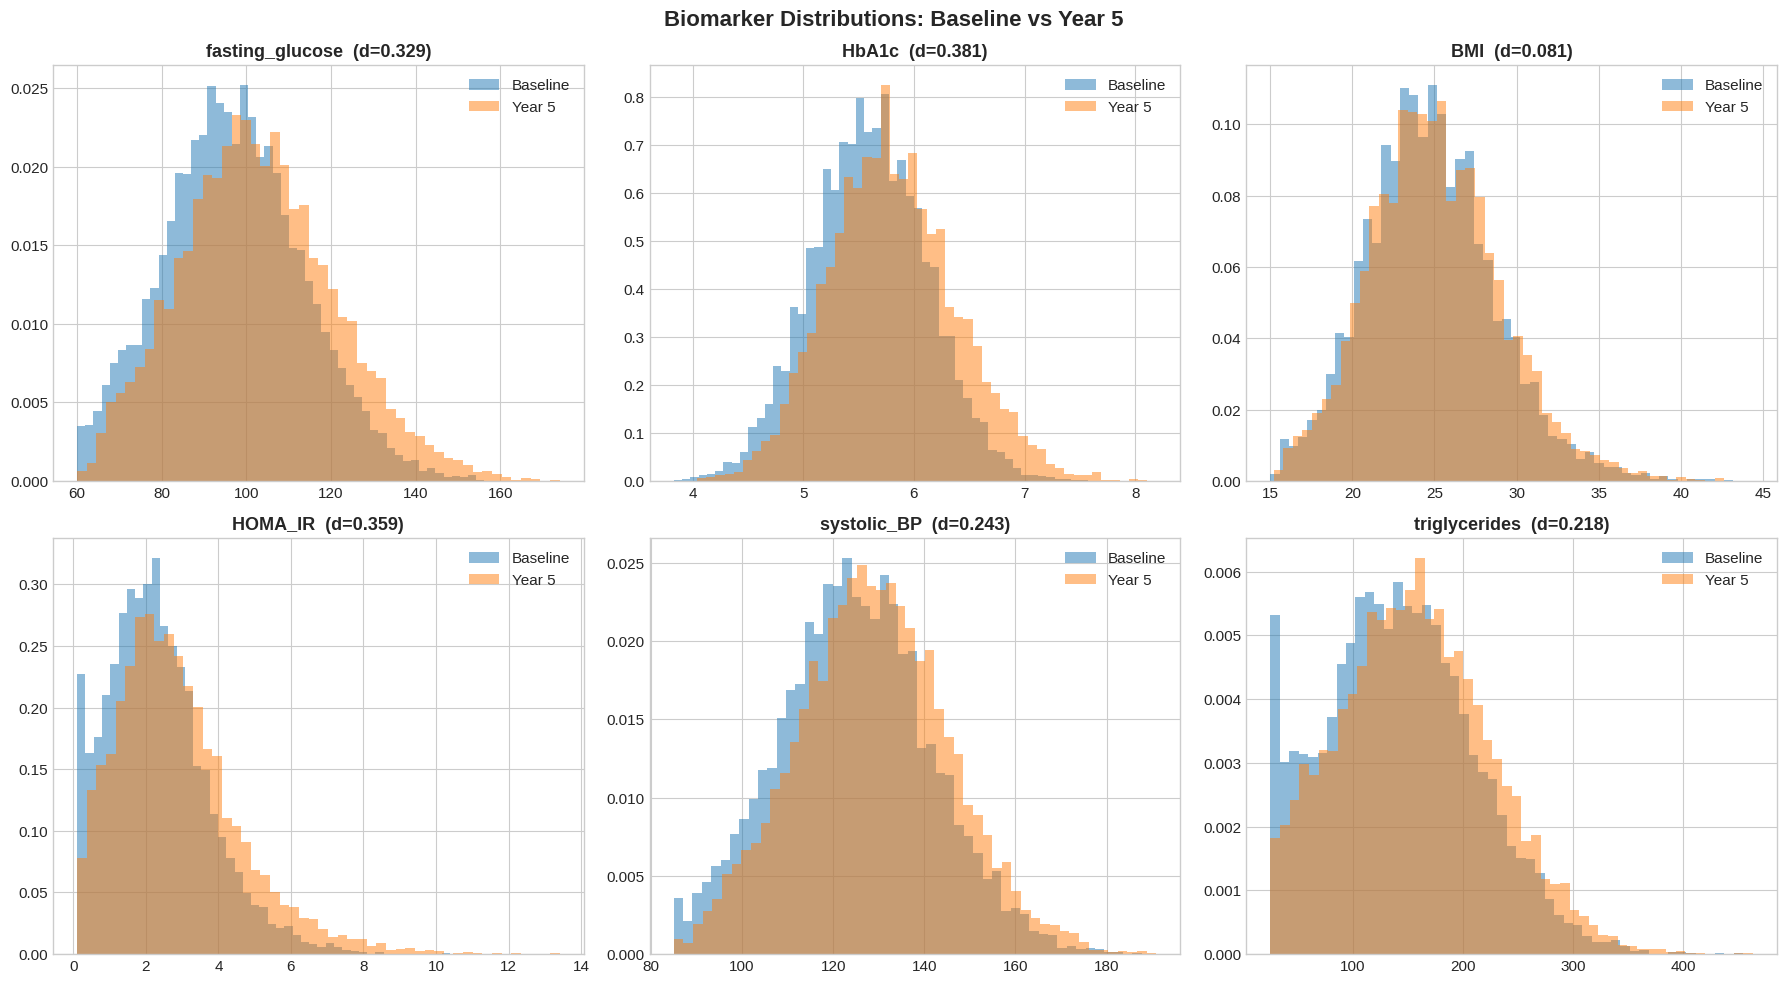

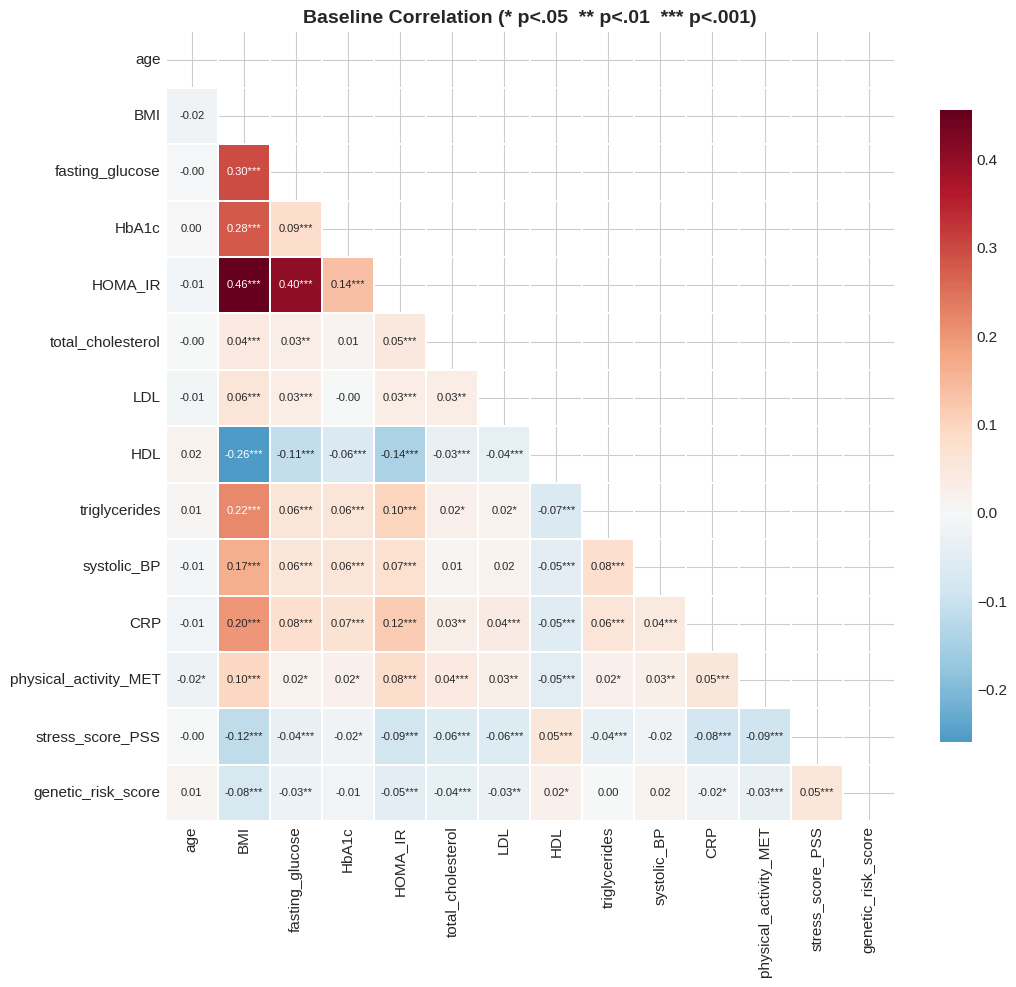

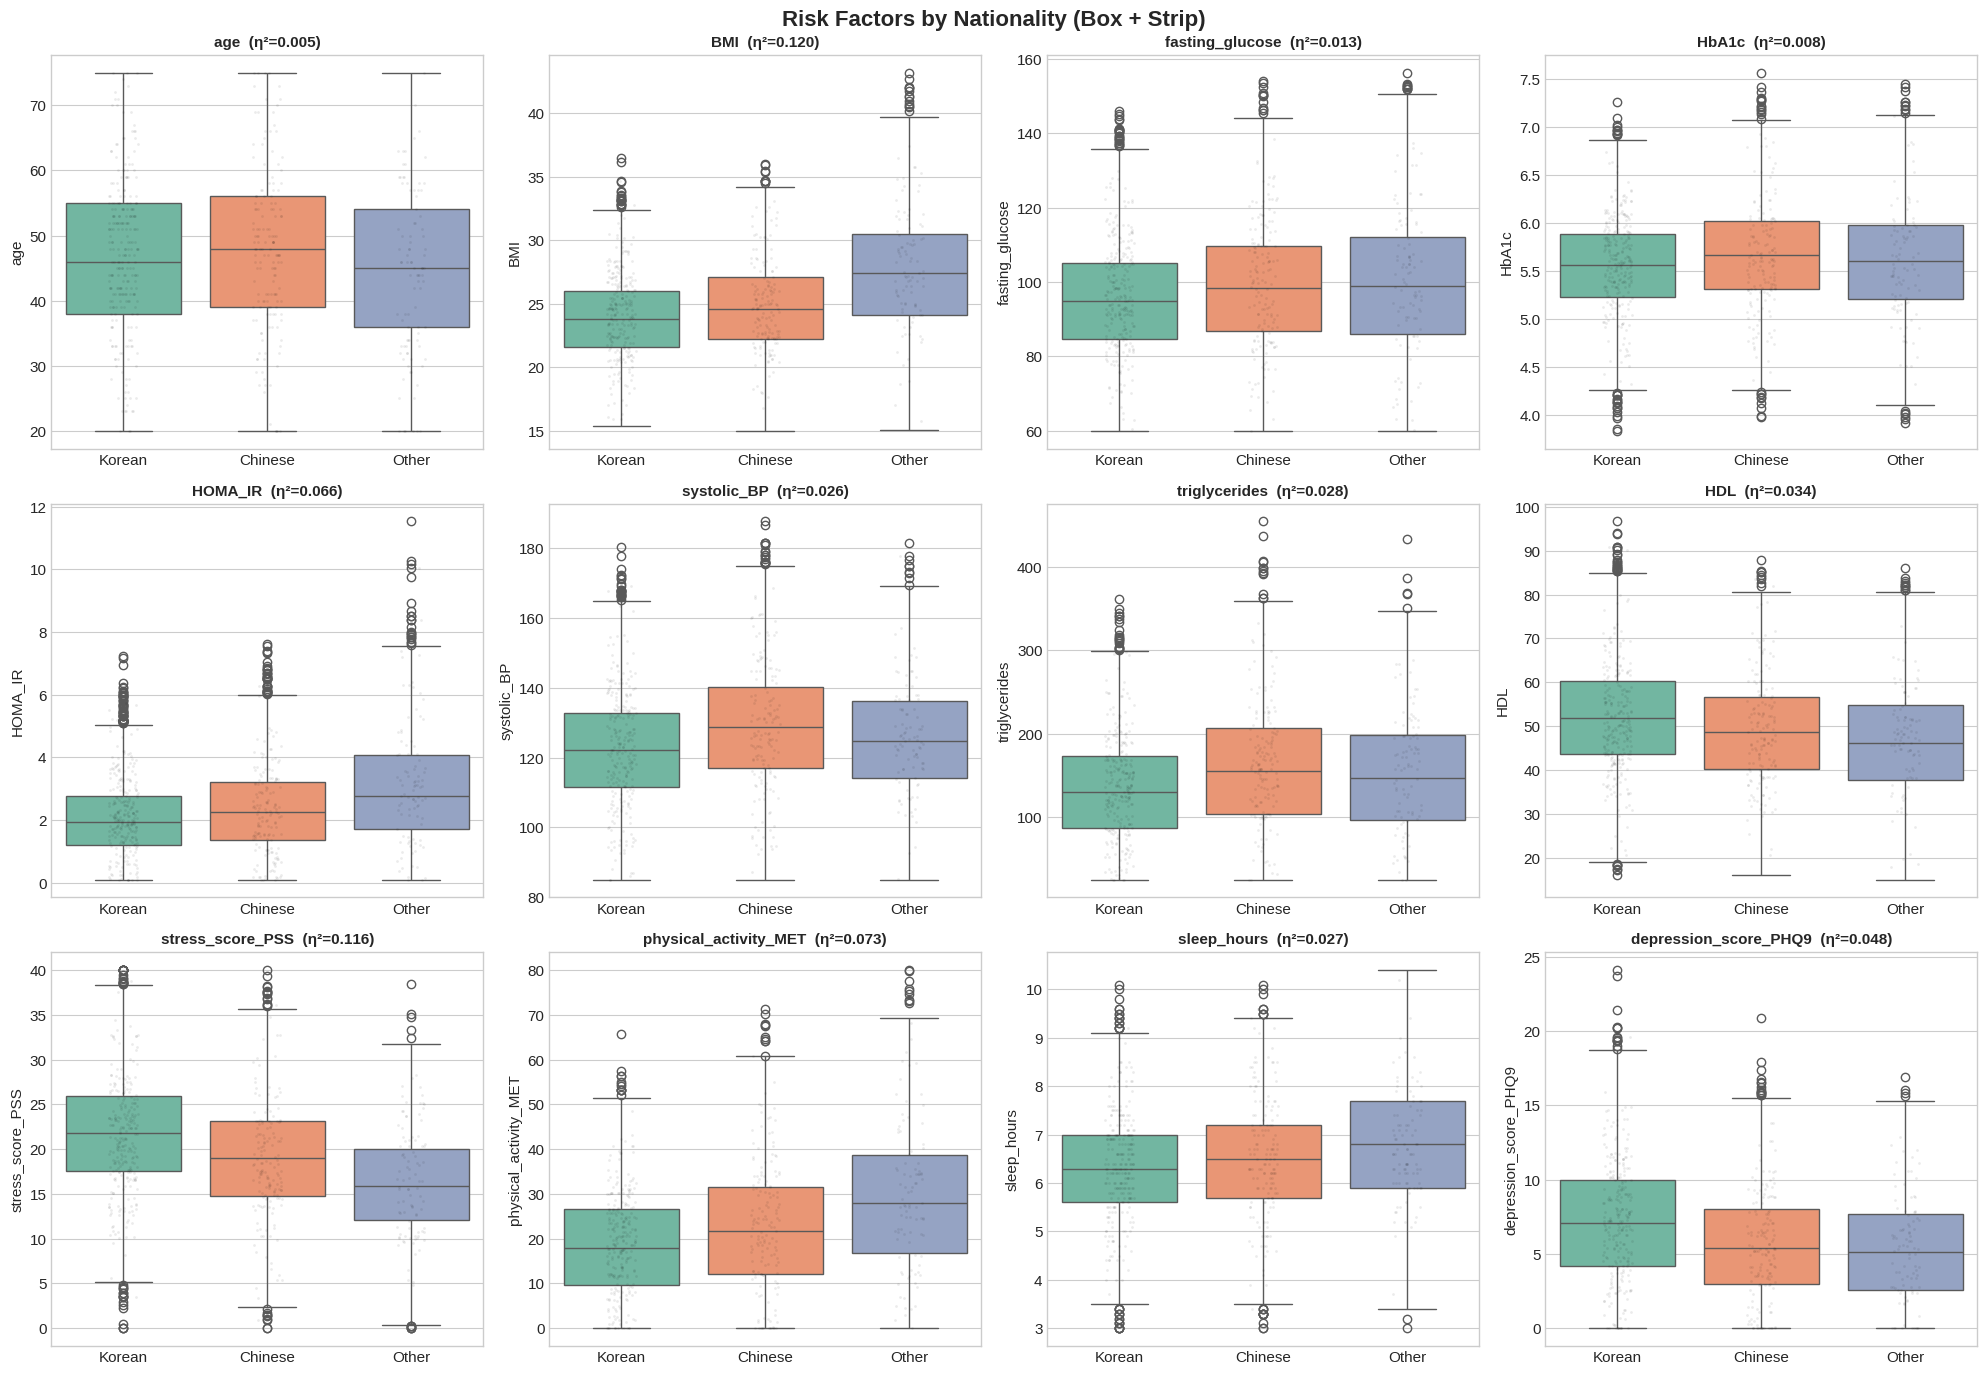

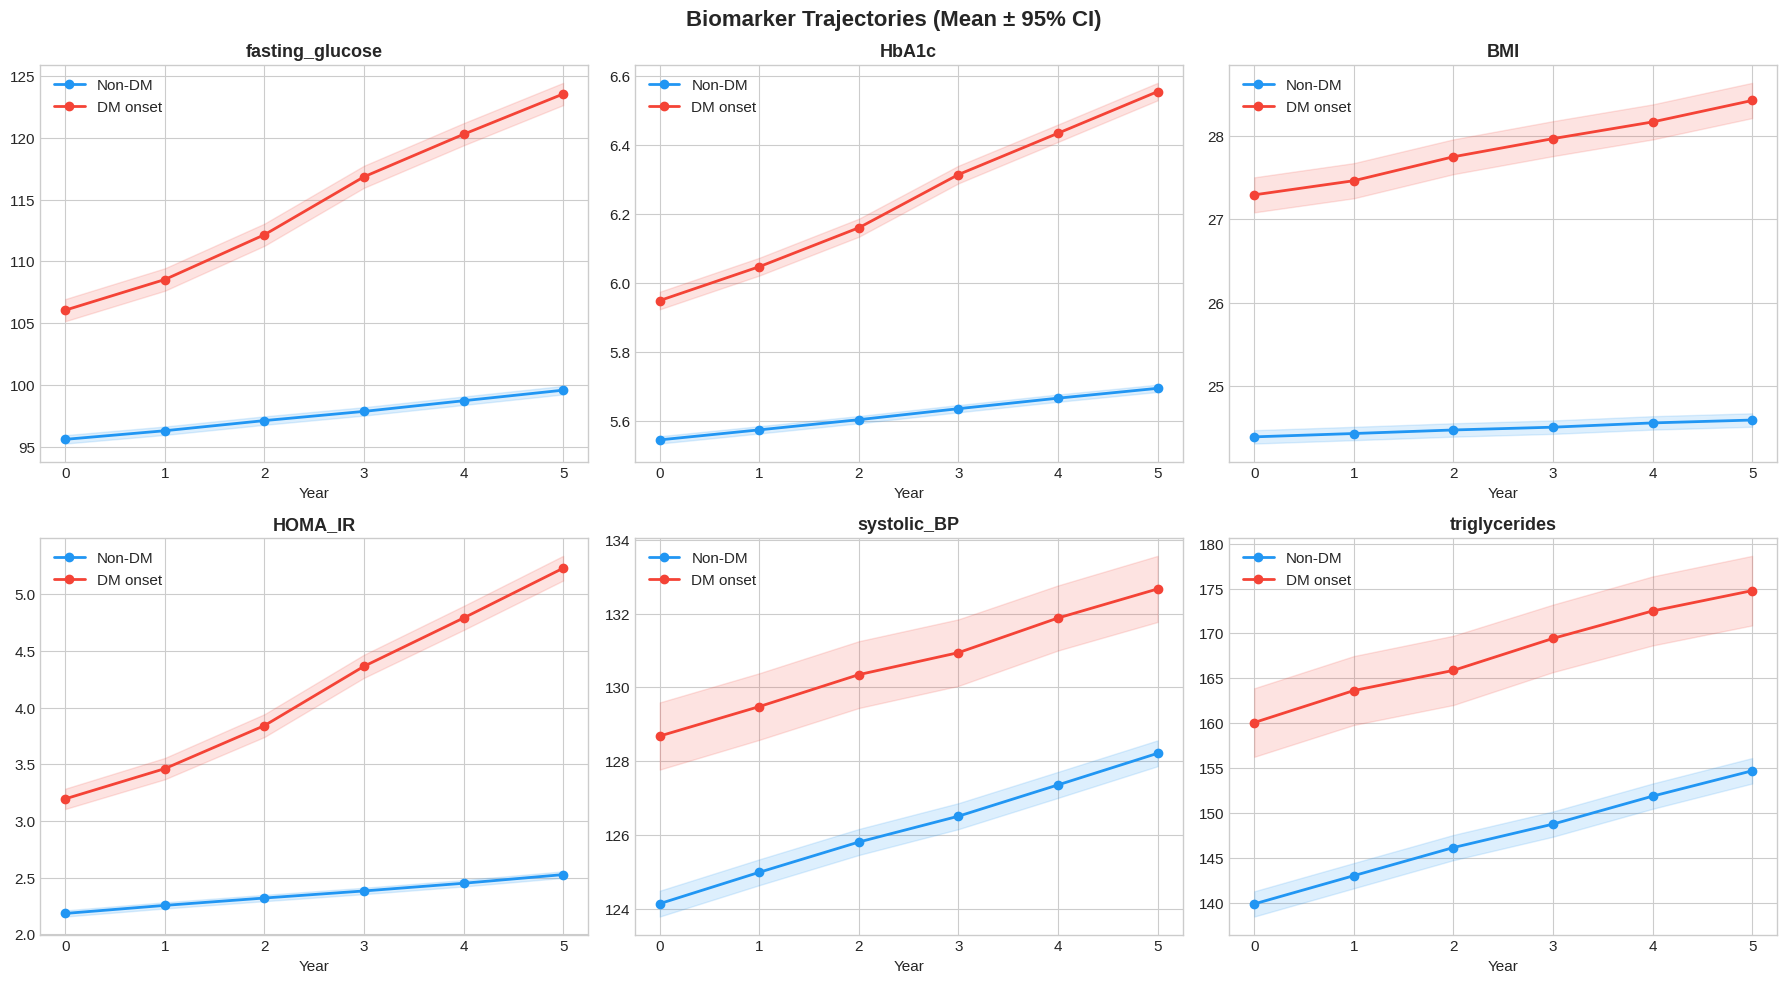

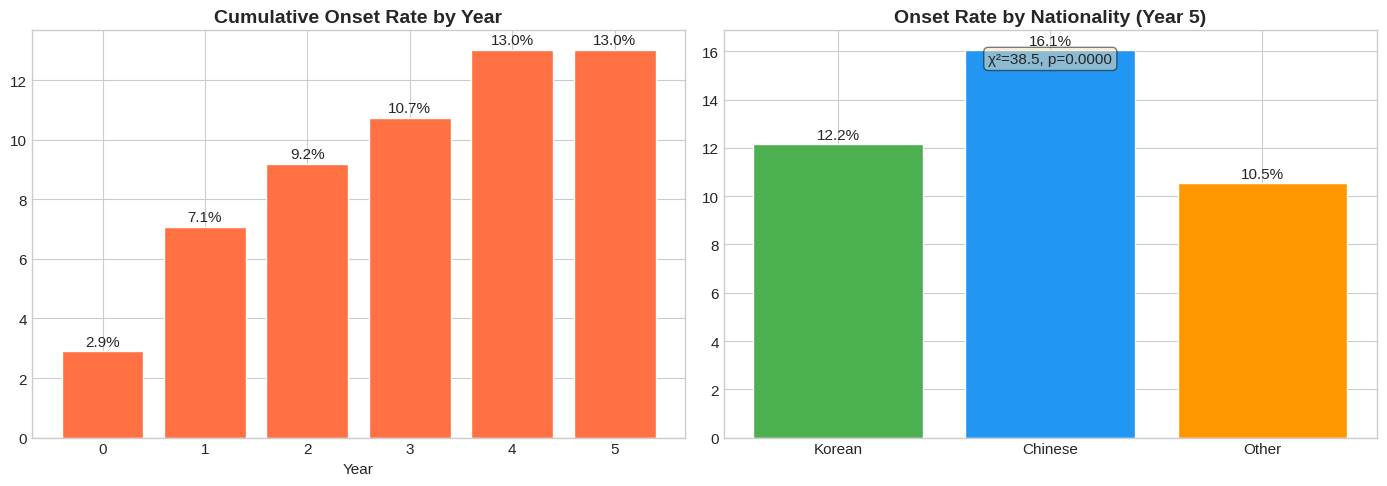


DM vs Non-DM (Baseline):
              Variable  NonDM_mean  DM_mean  Cohen_d sig
                   age     46.2732  48.9670    0.219 ***
                   BMI     24.3976  27.2919    0.760 ***
waist_circumference_cm     82.2636  88.1084    0.495 ***
       fasting_glucose     95.6531 106.0735    0.645 ***
                 HbA1c      5.5466   5.9503    0.806 ***
               HOMA_IR      2.1854   3.1958    0.747 ***
           systolic_BP    124.1348 128.6813    0.273 ***
                   HDL     50.3440  46.4099   -0.318 ***
         triglycerides    139.9124 160.0890    0.300 ***
                   CRP      1.9481   2.3818    0.228 ***
      stress_score_PSS     19.7056  20.5157    0.124 ***
    genetic_risk_score     51.4102  53.6225    0.143 ***

✅ EDA → /content/drive/MyDrive/2026_lecture/EBP_Medical/4week/output/01_EDA


In [1]:
#@title ⚙️📊 **CELL 1 / 3 : Environment · Data · EDA** (Run once)
# ── 1A. Install & Imports ──────────────────────────────────
from google.colab import drive; drive.mount('/content/drive')
!pip install -q lifelines xgboost shap optuna

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import os, warnings, torch, torch.nn as nn, torch.nn.functional as F
from scipy import stats
from itertools import combinations
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score, brier_score_loss,
                             classification_report, confusion_matrix, f1_score)
from sklearn.calibration import calibration_curve
from sklearn.manifold import TSNE
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test
import xgboost as xgb, shap, optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from torch.utils.data import Dataset, DataLoader

plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})
plt.style.use('seaborn-v0_8-whitegrid')
warnings.filterwarnings('ignore')

# ── 1B. Paths ──────────────────────────────────────────────
BASE   = '/content/drive/MyDrive/2026_lecture/EBP_Medical/4week'
INPUT  = f'{BASE}/input'
OUT    = {k: f'{BASE}/output/{k}' for k in ['01_EDA','02_Survival','03_ML','04_SHAP','05_DL']}
for p in OUT.values(): os.makedirs(p, exist_ok=True)

# ── 1C. Load & Preprocess ─────────────────────────────────
df       = pd.read_csv(f'{INPUT}/diabetes_cohort_10k_5yr.csv')
baseline = df[df['year']==0].copy()
final    = df[df['year']==5].copy()

miss = df.isnull().sum(); miss = miss[miss>0]
print('⚠️ Missing:' if len(miss) else '✅ No missing values', dict(miss) if len(miss) else '')

onset_ids = set(df.loc[df['diabetes_onset']==1, 'participant_id'])
df['final_onset'] = df['participant_id'].isin(onset_ids).astype(int)

# Survival frame (one row / person)
surv_rows = []
for pid in df['participant_id'].unique():
    s = df[df['participant_id']==pid].sort_values('year')
    bl, last = s.iloc[0], s.iloc[-1]
    e = int(last['diabetes_onset'])
    surv_rows.append(dict(
        participant_id=pid, duration_months=last['time_to_onset_months'] if e else 60, event=e,
        age=bl['age'], sex=int(bl['sex']=='M'), nationality=bl['nationality'],
        BMI=bl['BMI'], waist_cm=bl['waist_circumference_cm'],
        fasting_glucose=bl['fasting_glucose'], HbA1c=bl['HbA1c'],
        HOMA_IR=bl['HOMA_IR'], systolic_BP=bl['systolic_BP'],
        HDL=bl['HDL'], triglycerides=bl['triglycerides'],
        CRP=bl['CRP'], ALT=bl['ALT'],
        sleep_hours=bl['sleep_hours'], physical_activity_MET=bl['physical_activity_MET'],
        stress_score_PSS=bl['stress_score_PSS'], depression_score_PHQ9=bl['depression_score_PHQ9'],
        family_history=bl['family_history_diabetes'], genetic_risk=bl['genetic_risk_score'],
        smoking_current=int(bl['smoking_status']=='Current'),
        alcohol_heavy=int(bl['alcohol_frequency']=='Heavy')))
surv = pd.DataFrame(surv_rows)

# ML frame
outcome = df[df['year']==5][['participant_id','diabetes_onset']].rename(columns={'diabetes_onset':'y'})
ml = baseline.merge(outcome, on='participant_id')
ml['sex_num']          = (ml['sex']=='M').astype(int)
ml['smoking_current']  = (ml['smoking_status']=='Current').astype(int)
ml['smoking_former']   = (ml['smoking_status']=='Former').astype(int)
ml['alcohol_heavy']    = (ml['alcohol_frequency']=='Heavy').astype(int)
ml['alcohol_moderate'] = (ml['alcohol_frequency']=='Moderate').astype(int)
for n in ['Korean','Chinese','Other']: ml[f'nat_{n}'] = (ml['nationality']==n).astype(int)

FEAT = ['age','sex_num','BMI','waist_circumference_cm','body_fat_pct',
        'fasting_glucose','HbA1c','fasting_insulin','HOMA_IR',
        'total_cholesterol','LDL','HDL','triglycerides',
        'systolic_BP','diastolic_BP','ALT','creatinine','CRP',
        'sleep_hours','physical_activity_MET','sedentary_hours',
        'daily_calorie_intake','carb_intake_ratio',
        'stress_score_PSS','depression_score_PHQ9',
        'family_history_diabetes','genetic_risk_score',
        'smoking_current','smoking_former','alcohol_heavy','alcohol_moderate',
        'nat_Korean','nat_Chinese','nat_Other']
X, y = ml[FEAT].values, ml['y'].values
print(f'\nData: {df.shape[0]:,} rows, {df["participant_id"].nunique():,} subjects | Onset {int(y.sum())} ({y.mean()*100:.1f}%)')

# ── Helper ─────────────────────────────────────────────────
def cohens_d(a, b):
    n1, n2 = len(a), len(b)
    sp = np.sqrt(((n1-1)*a.std()**2+(n2-1)*b.std()**2)/(n1+n2-2))
    return (a.mean()-b.mean())/sp if sp else 0

def boot_auc(yt, yp, B=1000, seed=42):
    rng = np.random.RandomState(seed); aa=[]
    for _ in range(B):
        i = rng.choice(len(yt),len(yt),replace=True)
        if len(set(yt[i]))<2: continue
        aa.append(roc_auc_score(yt[i],yp[i]))
    return np.percentile(aa,[2.5,97.5])

# ═══════════════════════════  EDA  ═════════════════════════
O_eda = OUT['01_EDA']
NATS = ['Korean','Chinese','Other']

# ── 2a. Biomarker distributions + Cohen's d ───────────────
bio = ['fasting_glucose','HbA1c','BMI','HOMA_IR','systolic_BP','triglycerides']
fig, axes = plt.subplots(2,3,figsize=(18,10))
for i,v in enumerate(bio):
    ax = axes[i//3,i%3]
    ax.hist(baseline[v],bins=50,alpha=.5,label='Baseline',density=True)
    ax.hist(final[v],   bins=50,alpha=.5,label='Year 5',  density=True)
    d = cohens_d(final[v].dropna(), baseline[v].dropna())
    ax.set_title(f'{v}  (d={d:.3f})',fontsize=13,fontweight='bold'); ax.legend()
plt.suptitle('Biomarker Distributions: Baseline vs Year 5',fontsize=16,fontweight='bold')
plt.tight_layout(); plt.savefig(f'{O_eda}/biomarker_dist.png',dpi=300,bbox_inches='tight'); plt.show()

# ── 2b. Correlation heatmap with significance stars ───────
corr_v = ['age','BMI','fasting_glucose','HbA1c','HOMA_IR','total_cholesterol',
          'LDL','HDL','triglycerides','systolic_BP','CRP',
          'physical_activity_MET','stress_score_PSS','genetic_risk_score']
corr = baseline[corr_v].corr()
pmat = pd.DataFrame(1.0, index=corr_v, columns=corr_v)
for c1,c2 in combinations(corr_v,2):
    _,p = stats.pearsonr(baseline[c1].dropna(),baseline[c2].dropna())
    pmat.loc[c1,c2]=pmat.loc[c2,c1]=p
annot = corr.copy().astype(str)
for c1 in corr_v:
    for c2 in corr_v:
        s = '***' if pmat.loc[c1,c2]<.001 else '**' if pmat.loc[c1,c2]<.01 else '*' if pmat.loc[c1,c2]<.05 else ''
        annot.loc[c1,c2] = f'{corr.loc[c1,c2]:.2f}{s}'
fig,ax = plt.subplots(figsize=(11,10))
mask = np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap(corr,mask=mask,annot=annot,fmt='',cmap='RdBu_r',center=0,linewidths=.3,ax=ax,
            cbar_kws={'shrink':.8},annot_kws={'fontsize':8})
ax.set_title('Baseline Correlation (* p<.05  ** p<.01  *** p<.001)',fontsize=14,fontweight='bold')
plt.tight_layout(); plt.savefig(f'{O_eda}/correlation.png',dpi=300,bbox_inches='tight'); plt.show()

# ── 2c. Nationality ANOVA + η² + Bonferroni post-hoc ─────
compare = ['age','BMI','fasting_glucose','HbA1c','HOMA_IR','systolic_BP',
           'triglycerides','HDL','stress_score_PSS','physical_activity_MET',
           'sleep_hours','depression_score_PHQ9']
anova = []
for v in compare:
    grps = [baseline[baseline['nationality']==n][v].dropna() for n in NATS]
    F,p = stats.f_oneway(*grps)
    gm = baseline[v].mean()
    ssb = sum(len(g)*(g.mean()-gm)**2 for g in grps)
    sst = sum(((g-gm)**2).sum() for g in grps)
    eta2 = ssb/sst if sst else 0
    row = dict(Variable=v, F=round(F,2), p=p, eta2=round(eta2,4),
               sig='***' if p<.001 else '**' if p<.01 else '*' if p<.05 else 'ns')
    for n in NATS: row[f'{n}_mean']=baseline[baseline['nationality']==n][v].mean()
    for n1,n2 in combinations(range(3),2):
        _,pp = stats.mannwhitneyu(grps[n1],grps[n2]); row[f'{NATS[n1]}_v_{NATS[n2]}']=min(pp*3,1)
    anova.append(row)
anova_df = pd.DataFrame(anova).round(4)
anova_df.to_csv(f'{O_eda}/nationality_anova.csv',index=False)

fig,axes = plt.subplots(3,4,figsize=(20,14))
for i,v in enumerate(compare):
    ax=axes[i//4,i%4]
    sns.boxplot(data=baseline,x='nationality',y=v,ax=ax,order=NATS,palette='Set2')
    sns.stripplot(data=baseline.sample(min(500,len(baseline)),random_state=0),
                  x='nationality',y=v,ax=ax,order=NATS,color='black',alpha=.08,size=2)
    e2 = anova_df.loc[anova_df['Variable']==v,'eta2'].values[0]
    ax.set_title(f'{v}  (η²={e2:.3f})',fontsize=11,fontweight='bold'); ax.set_xlabel('')
plt.suptitle('Risk Factors by Nationality (Box + Strip)',fontsize=16,fontweight='bold')
plt.tight_layout(); plt.savefig(f'{O_eda}/nationality_boxplots.png',dpi=300,bbox_inches='tight'); plt.show()

# ── 2d. Trajectories by onset ─────────────────────────────
fig,axes = plt.subplots(2,3,figsize=(18,10))
for i,v in enumerate(bio):
    ax=axes[i//3,i%3]
    for g,lb,c in [(0,'Non-DM','#2196F3'),(1,'DM onset','#F44336')]:
        s=df[df['final_onset']==g].groupby('year')[v].agg(['mean','sem']).reset_index()
        ax.plot(s['year'],s['mean'],'o-',label=lb,color=c,lw=2)
        ax.fill_between(s['year'],s['mean']-1.96*s['sem'],s['mean']+1.96*s['sem'],alpha=.15,color=c)
    ax.set_title(v,fontsize=13,fontweight='bold'); ax.set_xlabel('Year'); ax.legend()
plt.suptitle('Biomarker Trajectories (Mean ± 95% CI)',fontsize=16,fontweight='bold')
plt.tight_layout(); plt.savefig(f'{O_eda}/trajectories.png',dpi=300,bbox_inches='tight'); plt.show()

# ── 2e. Onset rates + χ² ──────────────────────────────────
from scipy.stats import chi2_contingency
fig,axes = plt.subplots(1,2,figsize=(14,5))
yr=df.groupby('year')['diabetes_onset'].mean()*100
axes[0].bar(yr.index,yr.values,color='#FF7043',edgecolor='white')
for x,v in zip(yr.index,yr.values): axes[0].text(x,v+.2,f'{v:.1f}%',ha='center')
axes[0].set_title('Cumulative Onset Rate by Year',fontsize=14,fontweight='bold'); axes[0].set_xlabel('Year')
nr=final.groupby('nationality')['diabetes_onset'].mean()*100; nr=nr.reindex(NATS)
bars=axes[1].bar(nr.index,nr.values,color=['#4CAF50','#2196F3','#FF9800'],edgecolor='white')
for b,v in zip(bars,nr.values): axes[1].text(b.get_x()+b.get_width()/2,v+.2,f'{v:.1f}%',ha='center')
chi2,pchi,_,_=chi2_contingency(pd.crosstab(final['nationality'],final['diabetes_onset']))
axes[1].text(.5,.92,f'χ²={chi2:.1f}, p={pchi:.4f}',transform=axes[1].transAxes,ha='center',fontsize=11,
             bbox=dict(boxstyle='round',facecolor='wheat',alpha=.5))
axes[1].set_title('Onset Rate by Nationality (Year 5)',fontsize=14,fontweight='bold')
plt.tight_layout(); plt.savefig(f'{O_eda}/onset_rates.png',dpi=300,bbox_inches='tight'); plt.show()

# ── 2f. DM vs Non-DM baseline comparison ─────────────────
comp_vars = ['age','BMI','waist_circumference_cm','fasting_glucose','HbA1c','HOMA_IR',
             'systolic_BP','HDL','triglycerides','CRP','stress_score_PSS','genetic_risk_score']
rows = []
dm_ids = set(ml[ml['y']==1]['participant_id']); ndm_ids = set(ml[ml['y']==0]['participant_id'])
for v in comp_vars:
    g0=baseline[baseline['participant_id'].isin(ndm_ids)][v].dropna()
    g1=baseline[baseline['participant_id'].isin(dm_ids)][v].dropna()
    _,p=stats.mannwhitneyu(g0,g1)
    rows.append(dict(Variable=v, NonDM_mean=g0.mean(), DM_mean=g1.mean(),
                     Cohen_d=round(cohens_d(g1,g0),3), p=p,
                     sig='***' if p<.001 else '**' if p<.01 else '*' if p<.05 else 'ns'))
comp_df=pd.DataFrame(rows).round(4); comp_df.to_csv(f'{O_eda}/dm_vs_nondm.csv',index=False)
print('\nDM vs Non-DM (Baseline):')
print(comp_df[['Variable','NonDM_mean','DM_mean','Cohen_d','sig']].to_string(index=False))
print(f'\n✅ EDA → {O_eda}')


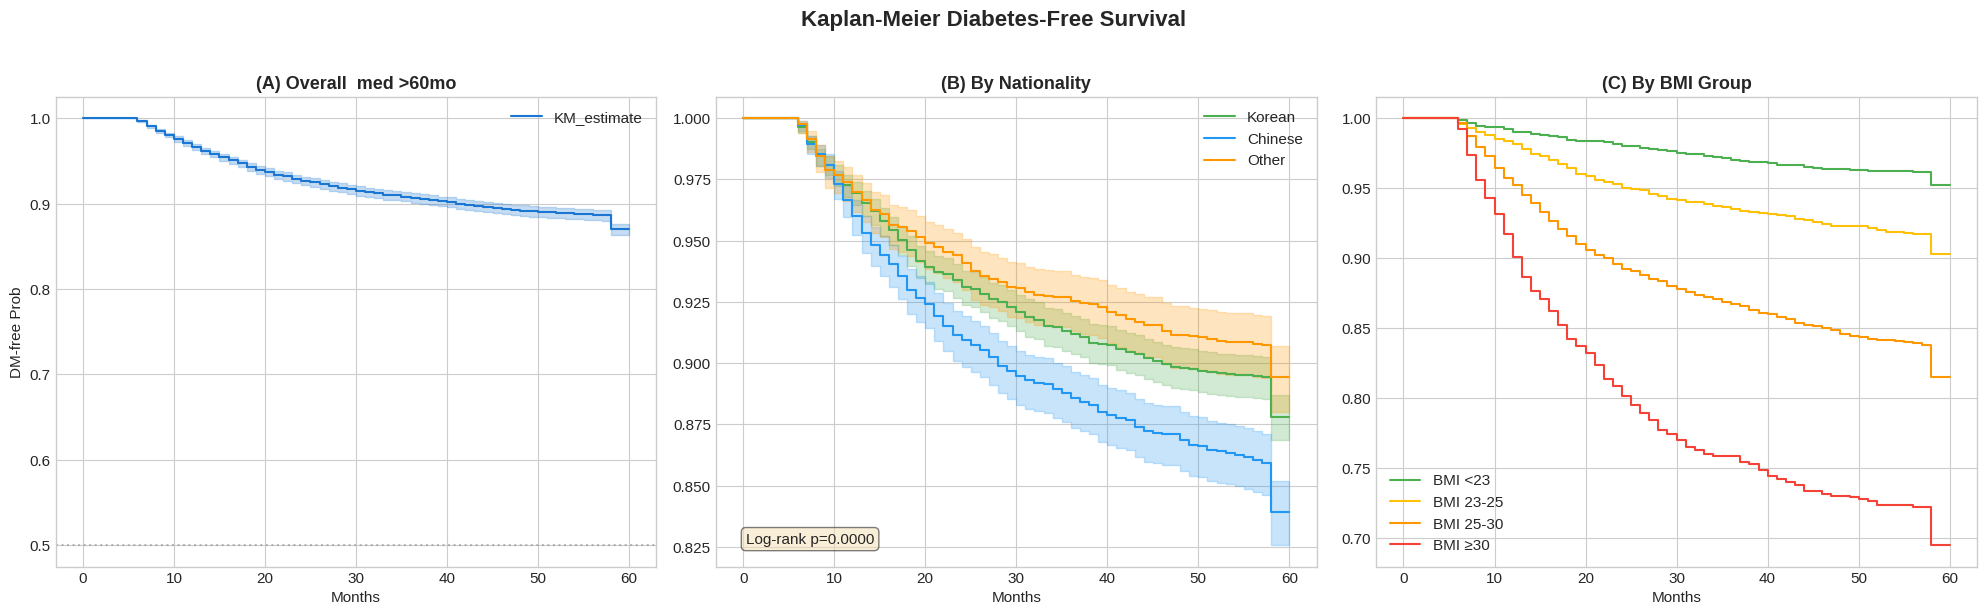

Cox C-index: 0.8059
The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'HbA1c' failed the non-proportional test: p-value is 0.0055.

   Advice 1: the functional form of the variable 'HbA1c' might be incorrect. That is, there may be
non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'HbA1c' using pd.cut, and then specify it in `strata=['HbA1c',
...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-ti

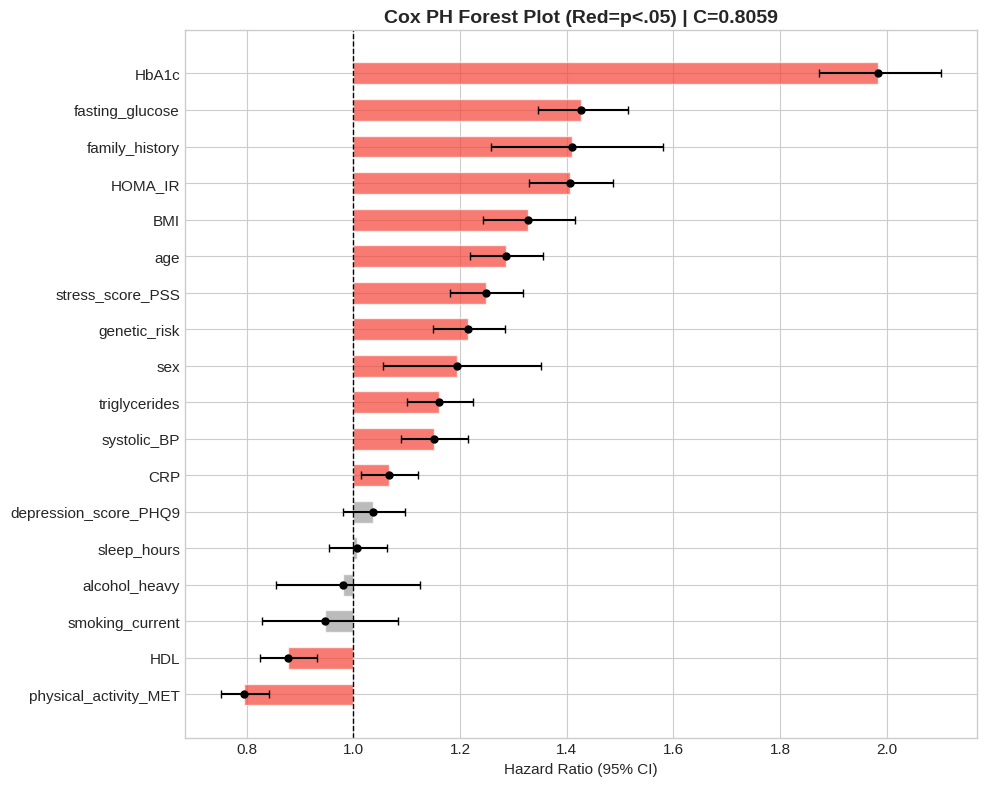

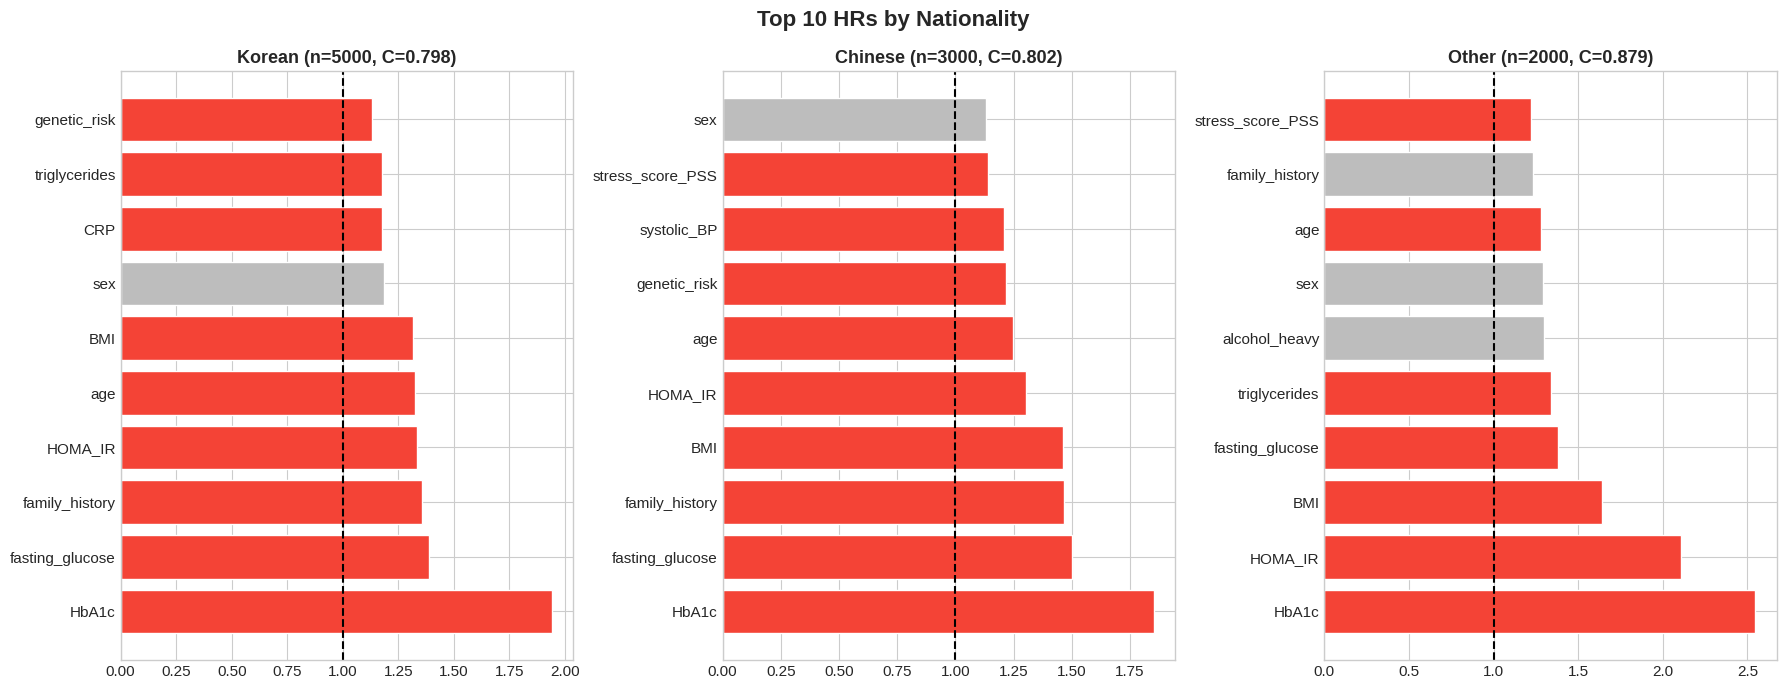

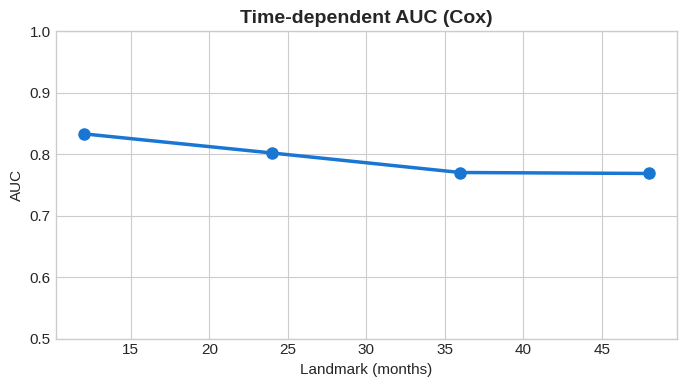

✅ Survival → /content/drive/MyDrive/2026_lecture/EBP_Medical/4week/output/02_Survival

  OPTUNA AUTO-TUNING — 50 trials × 3 models

🔍 [1/3] Logistic Regression...
  Best AUC = 0.8299 | params: C=0.0375, penalty=l1

🔍 [2/3] Random Forest...


In [ ]:
#@title 🔬🤖🔍 **CELL 2 / 3 : Survival · ML (All-Optuna) · SHAP** → 02~04
# ═════════════════  SURVIVAL  ══════════════════════════════
O_s = OUT['02_Survival']

# ── KM Curves ─────────────────────────────────────────────
fig,axes = plt.subplots(1,3,figsize=(20,6))
kmf=KaplanMeierFitter(); kmf.fit(surv['duration_months'],event_observed=surv['event'])
kmf.plot_survival_function(ax=axes[0],ci_show=True,color='#1976D2')
med=kmf.median_survival_time_
axes[0].axhline(.5,color='gray',ls=':',alpha=.5)
axes[0].set_title(f'(A) Overall  med={med:.0f}mo' if med!=np.inf else '(A) Overall  med >60mo',
                  fontsize=13,fontweight='bold')
axes[0].set_xlabel('Months'); axes[0].set_ylabel('DM-free Prob')

for n,c in [('Korean','#4CAF50'),('Chinese','#2196F3'),('Other','#FF9800')]:
    k=KaplanMeierFitter(); k.fit(surv.loc[surv['nationality']==n,'duration_months'],
                                  event_observed=surv.loc[surv['nationality']==n,'event'],label=n)
    k.plot_survival_function(ax=axes[1],ci_show=True,color=c)
lr=multivariate_logrank_test(surv['duration_months'],surv['nationality'],surv['event'])
axes[1].text(.05,.05,f'Log-rank p={lr.p_value:.4f}',transform=axes[1].transAxes,fontsize=11,
             bbox=dict(boxstyle='round',facecolor='wheat',alpha=.5))
axes[1].set_title('(B) By Nationality',fontsize=13,fontweight='bold'); axes[1].set_xlabel('Months')

surv['bmi_grp']=pd.cut(surv['BMI'],bins=[0,23,25,30,100],labels=['<23','23-25','25-30','≥30'])
for g,c in [('<23','#4CAF50'),('23-25','#FFC107'),('25-30','#FF9800'),('≥30','#F44336')]:
    m=surv['bmi_grp']==g
    k=KaplanMeierFitter(); k.fit(surv.loc[m,'duration_months'],event_observed=surv.loc[m,'event'],label=f'BMI {g}')
    k.plot_survival_function(ax=axes[2],ci_show=False,color=c)
axes[2].set_title('(C) By BMI Group',fontsize=13,fontweight='bold'); axes[2].set_xlabel('Months')
plt.suptitle('Kaplan-Meier Diabetes-Free Survival',fontsize=16,fontweight='bold',y=1.02)
plt.tight_layout(); plt.savefig(f'{O_s}/kaplan_meier.png',dpi=300,bbox_inches='tight'); plt.show()

# ── Cox PH ────────────────────────────────────────────────
cox_cols=['duration_months','event','age','sex','BMI','fasting_glucose','HbA1c','HOMA_IR',
          'systolic_BP','HDL','triglycerides','CRP','sleep_hours','physical_activity_MET',
          'stress_score_PSS','depression_score_PHQ9','family_history','genetic_risk',
          'smoking_current','alcohol_heavy']
cox_df=surv[cox_cols].copy()
cont=[c for c in cox_cols if c not in ['duration_months','event','sex','family_history','smoking_current','alcohol_heavy']]
for c in cont: cox_df[c]=(cox_df[c]-cox_df[c].mean())/cox_df[c].std()
cph=CoxPHFitter(); cph.fit(cox_df,duration_col='duration_months',event_col='event')
cph.summary.to_csv(f'{O_s}/cox_results.csv')
ci=cph.concordance_index_
print(f'Cox C-index: {ci:.4f}')
try: cph.check_assumptions(cox_df,p_value_threshold=0.05,show_plots=False)
except: pass

fig,ax=plt.subplots(figsize=(10,8))
hr=cph.summary[['exp(coef)','exp(coef) lower 95%','exp(coef) upper 95%','p']].sort_values('exp(coef)',ascending=True)
colors=['#F44336' if p<.05 else '#9E9E9E' for p in hr['p']]
ax.barh(range(len(hr)),hr['exp(coef)']-1,left=1,height=.6,color=colors,alpha=.7,edgecolor='white')
ax.errorbar(hr['exp(coef)'],range(len(hr)),
            xerr=[hr['exp(coef)']-hr['exp(coef) lower 95%'],hr['exp(coef) upper 95%']-hr['exp(coef)']],
            fmt='o',color='black',ms=5,capsize=3)
ax.axvline(1,color='black',ls='--',lw=1)
ax.set_yticks(range(len(hr))); ax.set_yticklabels(hr.index)
ax.set_xlabel('Hazard Ratio (95% CI)')
ax.set_title(f'Cox PH Forest Plot (Red=p<.05) | C={ci:.4f}',fontsize=14,fontweight='bold')
plt.tight_layout(); plt.savefig(f'{O_s}/forest_plot.png',dpi=300,bbox_inches='tight'); plt.show()

# Nationality subgroup
fig,axes=plt.subplots(1,3,figsize=(18,7))
for idx,nat in enumerate(NATS):
    sub=surv[surv['nationality']==nat][cox_cols].copy()
    for c in cont: sub[c]=(sub[c]-sub[c].mean())/sub[c].std()
    cp=CoxPHFitter(); cp.fit(sub,duration_col='duration_months',event_col='event')
    h=cp.summary[['exp(coef)','p']].sort_values('exp(coef)',ascending=False).head(10)
    cl=['#F44336' if p<.05 else '#BDBDBD' for p in h['p']]
    axes[idx].barh(range(len(h)),h['exp(coef)'],color=cl,edgecolor='white')
    axes[idx].axvline(1,color='black',ls='--')
    axes[idx].set_yticks(range(len(h))); axes[idx].set_yticklabels(h.index)
    axes[idx].set_title(f'{nat} (n={len(sub)}, C={cp.concordance_index_:.3f})',fontsize=13,fontweight='bold')
plt.suptitle('Top 10 HRs by Nationality',fontsize=16,fontweight='bold')
plt.tight_layout(); plt.savefig(f'{O_s}/cox_subgroup.png',dpi=300,bbox_inches='tight'); plt.show()

# Time-dependent AUC
td_auc=[]
for t in [12,24,36,48]:
    m=surv['duration_months']>=t; sub_t=surv[m]
    evt_t=((sub_t['duration_months']<=t+12)&(sub_t['event']==1)).astype(int)
    if evt_t.sum()<5 or evt_t.sum()==len(evt_t): continue
    lp=cph.predict_partial_hazard(cox_df.loc[m,[c for c in cox_cols if c not in ['duration_months','event']]])
    try: td_auc.append(dict(month=t,AUC=roc_auc_score(evt_t,lp),n=len(sub_t),events=int(evt_t.sum())))
    except: pass
if td_auc:
    td=pd.DataFrame(td_auc)
    fig,ax=plt.subplots(figsize=(7,4))
    ax.plot(td['month'],td['AUC'],'o-',color='#1976D2',lw=2.5,ms=8)
    ax.set_ylim(.5,1); ax.set_xlabel('Landmark (months)'); ax.set_ylabel('AUC')
    ax.set_title('Time-dependent AUC (Cox)',fontsize=14,fontweight='bold')
    plt.tight_layout(); plt.savefig(f'{O_s}/td_auc.png',dpi=300,bbox_inches='tight'); plt.show()
    td.to_csv(f'{O_s}/td_auc.csv',index=False)
print(f'✅ Survival → {O_s}')

# ═══════════════════════════════════════════════════════════
# ML — FULL OPTUNA AUTO-TUNING (All 3 Models)
# ═══════════════════════════════════════════════════════════
O_ml = OUT['03_ML']
cv = StratifiedKFold(5, shuffle=True, random_state=42)
scaler = StandardScaler()
pw = y.sum()/(len(y)-y.sum())

N_TRIALS = 50  # Optuna trials per model (increase for better search)
print(f'\n{"="*60}')
print(f'  OPTUNA AUTO-TUNING — {N_TRIALS} trials × 3 models')
print(f'{"="*60}')

# ── Logistic Regression Optuna ────────────────────────────
def lr_objective(trial):
    C = trial.suggest_float('C', 1e-4, 10, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1','l2','elasticnet'])
    solver = 'saga'
    params = dict(C=C, penalty=penalty, solver=solver, max_iter=2000,
                  class_weight='balanced', random_state=42, n_jobs=-1)
    if penalty == 'elasticnet':
        params['l1_ratio'] = trial.suggest_float('l1_ratio', 0.0, 1.0)
    Xs = scaler.fit_transform(X)
    yp = cross_val_predict(LogisticRegression(**params), Xs, y, cv=cv, method='predict_proba')[:,1]
    return roc_auc_score(y, yp)

print('\n🔍 [1/3] Logistic Regression...')
study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(lr_objective, n_trials=N_TRIALS)
bp_lr = study_lr.best_params
bp_lr.update(solver='saga', max_iter=2000, class_weight='balanced', random_state=42, n_jobs=-1)
print(f'  Best AUC = {study_lr.best_value:.4f} | params: C={bp_lr["C"]:.4f}, penalty={bp_lr["penalty"]}')

# ── Random Forest Optuna ──────────────────────────────────
def rf_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 100, 600),
        max_depth=trial.suggest_int('max_depth', 3, 15),
        min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 5, 50),
        max_features=trial.suggest_categorical('max_features', ['sqrt','log2', None]),
        class_weight='balanced', random_state=42, n_jobs=-1)
    yp = cross_val_predict(RandomForestClassifier(**params), X, y, cv=cv, method='predict_proba')[:,1]
    return roc_auc_score(y, yp)

print('\n🔍 [2/3] Random Forest...')
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(rf_objective, n_trials=N_TRIALS)
bp_rf = study_rf.best_params
bp_rf.update(class_weight='balanced', random_state=42, n_jobs=-1)
print(f'  Best AUC = {study_rf.best_value:.4f} | depth={bp_rf["max_depth"]}, leaf={bp_rf["min_samples_leaf"]}')

# ── XGBoost Optuna ────────────────────────────────────────
def xgb_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 100, 600),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        learning_rate=trial.suggest_float('learning_rate', .005, .3, log=True),
        subsample=trial.suggest_float('subsample', .5, 1.),
        colsample_bytree=trial.suggest_float('colsample_bytree', .4, 1.),
        min_child_weight=trial.suggest_int('min_child_weight', 1, 15),
        reg_alpha=trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        gamma=trial.suggest_float('gamma', 0, 5),
        scale_pos_weight=pw, eval_metric='logloss', random_state=42, n_jobs=-1)
    yp = cross_val_predict(xgb.XGBClassifier(**params), X, y, cv=cv, method='predict_proba')[:,1]
    return roc_auc_score(y, yp)

print('\n🔍 [3/3] XGBoost...')
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS)
bp_xgb = study_xgb.best_params
bp_xgb.update(scale_pos_weight=pw, eval_metric='logloss', random_state=42, n_jobs=-1)
print(f'  Best AUC = {study_xgb.best_value:.4f} | depth={bp_xgb["max_depth"]}, lr={bp_xgb["learning_rate"]:.4f}')

# ── Optuna Optimization History Plot ──────────────────────
fig, axes = plt.subplots(1,3,figsize=(20,5))
for ax, (nm, st, c) in zip(axes, [('Logistic', study_lr, '#2196F3'),
                                    ('Random Forest', study_rf, '#4CAF50'),
                                    ('XGBoost', study_xgb, '#F44336')]):
    trials = st.trials
    vals = [t.value for t in trials]
    best_so_far = [max(vals[:i+1]) for i in range(len(vals))]
    ax.plot(vals, 'o', alpha=.3, color=c, ms=4, label='Trial AUC')
    ax.plot(best_so_far, '-', color=c, lw=2.5, label='Best so far')
    ax.set_title(f'{nm}\nBest AUC = {st.best_value:.4f}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Trial'); ax.set_ylabel('AUC'); ax.legend()
plt.suptitle(f'Optuna Hyperparameter Search ({N_TRIALS} trials each)', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{O_ml}/optuna_history.png', dpi=300, bbox_inches='tight'); plt.show()

# ── Save best hyperparameters ─────────────────────────────
hp_summary = pd.DataFrame([
    {'Model':'Logistic Regression', 'Best_AUC': study_lr.best_value, **{k:v for k,v in study_lr.best_params.items()}},
    {'Model':'Random Forest', 'Best_AUC': study_rf.best_value, **{k:v for k,v in study_rf.best_params.items()}},
    {'Model':'XGBoost', 'Best_AUC': study_xgb.best_value, **{k:v for k,v in study_xgb.best_params.items()}},
])
hp_summary.to_csv(f'{O_ml}/optuna_best_params.csv', index=False)
print('\nBest hyperparameters saved → optuna_best_params.csv')

# ── Evaluate ALL tuned models ─────────────────────────────
print(f'\n{"="*60}')
print(f'  FINAL EVALUATION (all Optuna-tuned)')
print(f'{"="*60}')
models = {
    'LR (tuned)':  LogisticRegression(**bp_lr),
    'RF (tuned)':  RandomForestClassifier(**bp_rf),
    'XGB (tuned)': xgb.XGBClassifier(**bp_xgb),
}
# ── Comprehensive metrics helper ─────────────────────
def clf_metrics(y_true, y_prob, thr=None):
    from sklearn.metrics import (precision_score, recall_score, f1_score,
                                  matthews_corrcoef)
    if thr is None:
        prec_c,rec_c,thrs_c = precision_recall_curve(y_true,y_prob)
        f1s = 2*prec_c*rec_c/(prec_c+rec_c+1e-8)
        thr = thrs_c[np.argmax(f1s)]
    yhat = (y_prob >= thr).astype(int)
    tn,fp,fn,tp = confusion_matrix(y_true,yhat).ravel()
    return dict(
        AUC         = roc_auc_score(y_true,y_prob),
        AP          = average_precision_score(y_true,y_prob),
        Brier       = brier_score_loss(y_true,y_prob),
        Precision   = precision_score(y_true,yhat,zero_division=0),
        Recall      = recall_score(y_true,yhat),
        Specificity = tn/(tn+fp) if (tn+fp)>0 else 0,
        F1          = f1_score(y_true,yhat),
        PPV         = tp/(tp+fp) if (tp+fp)>0 else 0,
        NPV         = tn/(tn+fn) if (tn+fn)>0 else 0,
        MCC         = matthews_corrcoef(y_true,yhat),
        thr         = thr,
    )

res={}
for nm,m in models.items():
    Xi = scaler.fit_transform(X) if 'LR' in nm else X
    yp = cross_val_predict(m,Xi,y,cv=cv,method='predict_proba')[:,1]
    lo,hi = boot_auc(y,yp)
    mets = clf_metrics(y,yp)
    mets['AUC_CI_lo'],mets['AUC_CI_hi'] = lo,hi
    res[nm] = dict(prob=yp,**mets)
    print(f'  {nm:14s} AUC={mets["AUC"]:.4f}[{lo:.4f},{hi:.4f}]  '
          f'F1={mets["F1"]:.4f}  Sens={mets["Recall"]:.4f}  '
          f'Spec={mets["Specificity"]:.4f}  PPV={mets["PPV"]:.4f}  NPV={mets["NPV"]:.4f}')

# ── ROC / PR / Calibration ───────────────────────────────
clr={'LR (tuned)':'#2196F3','RF (tuned)':'#4CAF50','XGB (tuned)':'#F44336'}
fig,axes=plt.subplots(1,3,figsize=(21,6))
for nm,r in res.items():
    fpr,tpr,_=roc_curve(y,r['prob']); axes[0].plot(fpr,tpr,color=clr[nm],lw=2,label=f"{nm} ({r['AUC']:.3f})")
    pr,rc,_=precision_recall_curve(y,r['prob']); axes[1].plot(rc,pr,color=clr[nm],lw=2,label=f"{nm} ({r['AP']:.3f})")
    fp,mp=calibration_curve(y,r['prob'],n_bins=10,strategy='quantile'); axes[2].plot(mp,fp,'o-',color=clr[nm],lw=2,label=f"{nm} ({r['Brier']:.4f})")
axes[0].plot([0,1],[0,1],'k--',alpha=.3); axes[0].set_title('ROC',fontsize=14,fontweight='bold'); axes[0].legend(fontsize=10)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[1].set_title('Precision-Recall',fontsize=14,fontweight='bold'); axes[1].legend(fontsize=10)
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[2].plot([0,1],[0,1],'k--',alpha=.3); axes[2].set_title('Calibration',fontsize=14,fontweight='bold'); axes[2].legend(fontsize=10)
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Observed')
plt.tight_layout(); plt.savefig(f'{O_ml}/roc_pr_cal.png',dpi=300,bbox_inches='tight'); plt.show()

# ── Metrics summary table ────────────────────────────────
MCOLS = ['AUC','AP','Brier','Precision','Recall','Specificity','F1','PPV','NPV','MCC']
smry = pd.DataFrame({nm:{k:round(res[nm][k],4) for k in MCOLS} for nm in res}).T
print('\nComprehensive Metrics (Optimal F1 threshold):')
print(smry.to_string())
smry.to_csv(f'{O_ml}/summary.csv')

# Radar chart
R_MET = ['AUC','AP','Precision','Recall','Specificity','F1','NPV']
NR = len(R_MET)
angles = np.linspace(0,2*np.pi,NR,endpoint=False).tolist(); angles += angles[:1]
fig,ax = plt.subplots(figsize=(8,8),subplot_kw=dict(polar=True))
for nm,r in res.items():
    vals = [r[m] for m in R_MET]; vals += vals[:1]
    ax.plot(angles,vals,'o-',color=clr[nm],lw=2,label=nm)
    ax.fill(angles,vals,alpha=0.07,color=clr[nm])
ax.set_xticks(angles[:-1]); ax.set_xticklabels(R_MET,fontsize=12)
ax.set_ylim(0,1); ax.set_title('Model Performance Radar',fontsize=15,fontweight='bold',pad=20)
ax.legend(loc='upper right',bbox_to_anchor=(1.3,1.1))
plt.tight_layout(); plt.savefig(f'{O_ml}/radar_chart.png',dpi=300,bbox_inches='tight'); plt.show()

# ── Confusion matrix (best model) ────────────────────────
best_nm=max(res,key=lambda k:res[k]['AUC']); best_p=res[best_nm]['prob']
opt_t=res[best_nm]['thr']; yhat=(best_p>=opt_t).astype(int)
fig,axes=plt.subplots(1,2,figsize=(12,5))
cm=confusion_matrix(y,yhat)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=axes[0],
            xticklabels=['No DM','DM'],yticklabels=['No DM','DM'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title(f'{best_nm} | thr={opt_t:.3f}',fontsize=13,fontweight='bold')
cm_n=cm.astype(float)/cm.sum(axis=1,keepdims=True)
sns.heatmap(cm_n,annot=True,fmt='.3f',cmap='Blues',ax=axes[1],
            xticklabels=['No DM','DM'],yticklabels=['No DM','DM'])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
axes[1].set_title('Normalized Confusion Matrix',fontsize=13,fontweight='bold')
plt.tight_layout(); plt.savefig(f'{O_ml}/confusion.png',dpi=300,bbox_inches='tight'); plt.show()
print(classification_report(y,yhat,target_names=['No DM','DM']))

# ── Feature importance ────────────────────────────────────
xgb_full=xgb.XGBClassifier(**bp_xgb); xgb_full.fit(X,y)
imp=pd.DataFrame(dict(feature=FEAT,importance=xgb_full.feature_importances_)).sort_values('importance',ascending=False)
fig,ax=plt.subplots(figsize=(10,9)); t20=imp.head(20)
ax.barh(range(len(t20)),t20['importance'].values,color='#FF7043',edgecolor='white')
ax.set_yticks(range(len(t20))); ax.set_yticklabels(t20['feature']); ax.invert_yaxis()
ax.set_title('XGB (Optuna-tuned) Top 20 Features',fontsize=14,fontweight='bold')
plt.tight_layout(); plt.savefig(f'{O_ml}/feature_importance.png',dpi=300,bbox_inches='tight'); plt.show()
imp.to_csv(f'{O_ml}/feature_importance.csv',index=False)
# summary already saved above
print(f'✅ ML → {O_ml}')

# ═════════════════  SHAP  ═════════════════════════════════
O_sh = OUT['04_SHAP']
explainer = shap.TreeExplainer(xgb_full)
shap_vals = explainer.shap_values(ml[FEAT])

fig,axes=plt.subplots(1,2,figsize=(20,9))
plt.sca(axes[0]); shap.summary_plot(shap_vals,ml[FEAT],max_display=20,show=False); axes[0].set_title('Beeswarm')
plt.sca(axes[1]); shap.summary_plot(shap_vals,ml[FEAT],plot_type='bar',max_display=20,show=False); axes[1].set_title('Mean |SHAP|')
plt.tight_layout(); plt.savefig(f'{O_sh}/shap_summary.png',dpi=300,bbox_inches='tight'); plt.show()

nats_m = {n: ml['nationality']==n for n in NATS}
shap_nat = {n: np.abs(shap_vals[m.values]).mean(0) for n,m in nats_m.items()}
sc = pd.DataFrame(shap_nat,index=FEAT)
sc['Overall']=np.abs(shap_vals).mean(0); sc=sc.sort_values('Overall',ascending=False)
fig,ax=plt.subplots(figsize=(10,9))
sns.heatmap(sc.head(15)[NATS],annot=True,fmt='.4f',cmap='YlOrRd',ax=ax,linewidths=.5)
ax.set_title('Top 15 SHAP by Nationality',fontsize=14,fontweight='bold')
plt.tight_layout(); plt.savefig(f'{O_sh}/shap_nationality.png',dpi=300,bbox_inches='tight'); plt.show()

fig,axes=plt.subplots(1,3,figsize=(18,8))
for idx,(nat,c) in enumerate([('Korean','#4CAF50'),('Chinese','#2196F3'),('Other','#FF9800')]):
    t10=pd.Series(shap_nat[nat],index=FEAT).nlargest(10)
    axes[idx].barh(range(10),t10.values,color=c,edgecolor='white')
    axes[idx].set_yticks(range(10)); axes[idx].set_yticklabels(t10.index); axes[idx].invert_yaxis()
    axes[idx].set_title(f'{nat} (n={nats_m[nat].sum()})',fontsize=13,fontweight='bold')
plt.suptitle('SHAP Top 10 by Nationality',fontsize=16,fontweight='bold')
plt.tight_layout(); plt.savefig(f'{O_sh}/shap_top10.png',dpi=300,bbox_inches='tight'); plt.show()

keys=['HbA1c','fasting_glucose','BMI','HOMA_IR','age','stress_score_PSS']
fig,axes=plt.subplots(2,3,figsize=(18,10))
for i,v in enumerate(keys):
    ax=axes[i//3,i%3]; ci_idx=FEAT.index(v)
    ax.scatter(ml[FEAT][v],shap_vals[:,ci_idx],
               c=ml['nationality'].map({'Korean':0,'Chinese':1,'Other':2}),cmap='Set1',alpha=.3,s=5)
    ax.set_xlabel(v); ax.set_ylabel('SHAP'); ax.axhline(0,color='gray',ls='--',alpha=.3)
    ax.set_title(f'{v}',fontsize=12,fontweight='bold')
from matplotlib.lines import Line2D
fig.legend(handles=[Line2D([0],[0],marker='o',color='w',markerfacecolor=c,ms=8,label=n)
           for n,c in zip(NATS,['#E41A1C','#377EB8','#4DAF4A'])],loc='upper right')
plt.suptitle('SHAP Dependence (color=Nationality)',fontsize=16,fontweight='bold')
plt.tight_layout(); plt.savefig(f'{O_sh}/shap_dependence.png',dpi=300,bbox_inches='tight'); plt.show()

shap_exp=shap.Explanation(values=shap_vals,base_values=explainer.expected_value,
                          data=ml[FEAT].values,feature_names=FEAT)
dm_i=ml[ml['y']==1].index; ndm_i=ml[ml['y']==0].index
hi_idx=dm_i[np.argmax(xgb_full.predict_proba(ml.loc[dm_i,FEAT])[:,1])]
lo_idx=ndm_i[np.argmin(xgb_full.predict_proba(ml.loc[ndm_i,FEAT])[:,1])]
fig,axes=plt.subplots(1,2,figsize=(20,7))
plt.sca(axes[0]); shap.plots.waterfall(shap_exp[ml.index.get_loc(hi_idx)],max_display=12,show=False)
axes[0].set_title('Highest-Risk DM',fontweight='bold')
plt.sca(axes[1]); shap.plots.waterfall(shap_exp[ml.index.get_loc(lo_idx)],max_display=12,show=False)
axes[1].set_title('Lowest-Risk Non-DM',fontweight='bold')
plt.tight_layout(); plt.savefig(f'{O_sh}/shap_waterfall.png',dpi=300,bbox_inches='tight'); plt.show()

try:
    si=explainer.shap_interaction_values(ml[FEAT].head(500))
    im=np.abs(si).mean(0); np.fill_diagonal(im,0)
    tp=np.unravel_index(np.argmax(im),im.shape)
    fig,ax=plt.subplots(figsize=(8,6))
    shap.dependence_plot(tp[0],shap_vals[:500],ml[FEAT].head(500),interaction_index=tp[1],ax=ax,show=False)
    ax.set_title(f'Top Interaction: {FEAT[tp[0]]} × {FEAT[tp[1]]}',fontsize=13,fontweight='bold')
    plt.tight_layout(); plt.savefig(f'{O_sh}/shap_interaction.png',dpi=300,bbox_inches='tight'); plt.show()
except Exception as e: print(f'Interaction skipped: {e}')
sc.to_csv(f'{O_sh}/shap_comparison.csv')
print(f'✅ SHAP → {O_sh}')


In [ ]:
#@title 🧠 **CELL 3 / 3 : Deep Learning — LSTM · GRU · Transformer (Optuna Auto-Tuned)** → 05_DL/
O_dl = OUT['05_DL']
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ═══════════════  DATA  ═══════════════════════════════════
TEMP = ['BMI','waist_circumference_cm','body_fat_pct','fasting_glucose','HbA1c',
        'fasting_insulin','HOMA_IR','total_cholesterol','LDL','HDL','triglycerides',
        'systolic_BP','diastolic_BP','ALT','creatinine','CRP',
        'sleep_hours','physical_activity_MET','sedentary_hours',
        'stress_score_PSS','depression_score_PHQ9']
STAT = ['age','family_history_diabetes','genetic_risk_score']

ssc_t, ssc_s = StandardScaler(), StandardScaler()
ssc_t.fit(df[df['year']<=4][TEMP].values); ssc_s.fit(df[df['year']==0][STAT].values)
pids = df['participant_id'].unique()
omap = df[df['year']==5].set_index('participant_id')['diabetes_onset']
nmap = df[df['year']==0].set_index('participant_id')['nationality']

Xt, Xs, Ydl, Ndl = [], [], [], []
for pid in pids:
    s=df[(df['participant_id']==pid)&(df['year']<=4)].sort_values('year')
    if len(s)==5:
        Xt.append(ssc_t.transform(s[TEMP].values))
        Xs.append(ssc_s.transform([s.iloc[0][STAT].values])[0])
        Ydl.append(omap.loc[pid]); Ndl.append(nmap.loc[pid])
Xt=np.array(Xt,dtype=np.float32); Xs=np.array(Xs,dtype=np.float32)
Ydl=np.array(Ydl,dtype=np.float32); Ndl=np.array(Ndl)

Xt_delta = np.diff(Xt, axis=1, prepend=Xt[:,:1,:])
Xt_aug = np.concatenate([Xt, Xt_delta], axis=-1)
print(f'Temporal: {Xt_aug.shape}, Static: {Xs.shape}, Onset: {Ydl.mean():.3f}')

idx_tr,idx_te = train_test_split(np.arange(len(Ydl)),test_size=.2,stratify=Ydl,random_state=42)
Xtr,Xte = Xt_aug[idx_tr],Xt_aug[idx_te]
Xsr,Xse = Xs[idx_tr],Xs[idx_te]
ytr,yte = Ydl[idx_tr],Ydl[idx_te]
nte = Ndl[idx_te]

class DS(Dataset):
    def __init__(s,xt,xs,y):
        s.xt,s.xs,s.y = torch.FloatTensor(xt),torch.FloatTensor(xs),torch.FloatTensor(y)
    def __len__(s): return len(s.y)
    def __getitem__(s,i): return s.xt[i],s.xs[i],s.y[i]

pw_t = torch.tensor([(len(ytr)-ytr.sum())/ytr.sum()]).to(device)
idim, sdim = Xt_aug.shape[-1], Xs.shape[-1]

# ═══════════════  ARCHITECTURES  ══════════════════════════

class LSTMAttn(nn.Module):
    def __init__(s,idim,sdim,h=64,nl=2,do=.3):
        super().__init__()
        s.lstm=nn.LSTM(idim,h,nl,batch_first=True,dropout=do if nl>1 else 0,bidirectional=True)
        s.attn=nn.Sequential(nn.Linear(h*2,h),nn.Tanh(),nn.Linear(h,1))
        s.cls=nn.Sequential(nn.Linear(h*2+sdim,64),nn.ReLU(),nn.Dropout(do),
                            nn.Linear(64,32),nn.ReLU(),nn.Dropout(do),nn.Linear(32,1))
    def forward(s,xt,xs):
        o,_=s.lstm(xt); w=torch.softmax(s.attn(o),dim=1); ctx=(o*w).sum(1)
        return s.cls(torch.cat([ctx,xs],1)).squeeze(-1), w.squeeze(-1)
    def get_repr(s,xt,xs):
        o,_=s.lstm(xt); w=torch.softmax(s.attn(o),dim=1); return (o*w).sum(1)

class GRUAttn(nn.Module):
    def __init__(s,idim,sdim,h=64,nl=2,do=.3):
        super().__init__()
        s.gru=nn.GRU(idim,h,nl,batch_first=True,dropout=do if nl>1 else 0,bidirectional=True)
        s.attn=nn.Sequential(nn.Linear(h*2,h),nn.Tanh(),nn.Linear(h,1))
        s.cls=nn.Sequential(nn.Linear(h*2+sdim,64),nn.ReLU(),nn.Dropout(do),
                            nn.Linear(64,32),nn.ReLU(),nn.Dropout(do),nn.Linear(32,1))
    def forward(s,xt,xs):
        o,_=s.gru(xt); w=torch.softmax(s.attn(o),dim=1); ctx=(o*w).sum(1)
        return s.cls(torch.cat([ctx,xs],1)).squeeze(-1), w.squeeze(-1)
    def get_repr(s,xt,xs):
        o,_=s.gru(xt); w=torch.softmax(s.attn(o),dim=1); return (o*w).sum(1)

class PosEnc(nn.Module):
    def __init__(s,d,mx=10):
        super().__init__()
        pe=torch.zeros(mx,d); pos=torch.arange(mx).unsqueeze(1).float()
        div=torch.exp(torch.arange(0,d,2).float()*-(np.log(10000)/d))
        pe[:,0::2]=torch.sin(pos*div)
        if d>1: pe[:,1::2]=torch.cos(pos*div[:d//2])
        s.register_buffer('pe',pe.unsqueeze(0))
    def forward(s,x): return x+s.pe[:,:x.size(1)]

class TransformerPred(nn.Module):
    def __init__(s,idim,sdim,dm=128,nh=4,nl=3,do=.3):
        super().__init__()
        s.proj=nn.Linear(idim,dm); s.pe=PosEnc(dm)
        el=nn.TransformerEncoderLayer(dm,nh,dm*4,do,batch_first=True,activation='gelu')
        s.enc=nn.TransformerEncoder(el,nl)
        s.cls_tok=nn.Parameter(torch.randn(1,1,dm)*.02)
        s.cls=nn.Sequential(nn.Linear(dm+sdim,64),nn.GELU(),nn.Dropout(do),
                            nn.Linear(64,32),nn.GELU(),nn.Dropout(do),nn.Linear(32,1))
        s.ap=nn.Linear(dm,1)
    def forward(s,xt,xs):
        B=xt.size(0); h=s.pe(s.proj(xt))
        h=s.enc(torch.cat([s.cls_tok.expand(B,-1,-1),h],1))
        w=torch.softmax(s.ap(h[:,1:]),dim=1).squeeze(-1)
        return s.cls(torch.cat([h[:,0],xs],1)).squeeze(-1), w
    def get_repr(s,xt,xs):
        B=xt.size(0); h=s.pe(s.proj(xt))
        return s.enc(torch.cat([s.cls_tok.expand(B,-1,-1),h],1))[:,0]

# ═══════════════  OPTUNA DL TUNING  ═══════════════════════
DL_TRIALS = 20  # trials per architecture (each trial = full training)
DL_TUNE_EPOCHS = 30  # shorter epochs for tuning phase

def quick_train(model, lr, batch_size, epochs=DL_TUNE_EPOCHS):
    """Fast training for Optuna evaluation"""
    crit = nn.BCEWithLogitsLoss(pos_weight=pw_t)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    trdl = DataLoader(DS(Xtr,Xsr,ytr), batch_size=batch_size, shuffle=True, drop_last=True)
    tedl = DataLoader(DS(Xte,Xse,yte), batch_size=256)
    best = 0
    for ep in range(epochs):
        model.train()
        for xb,sb,yb in trdl:
            xb,sb,yb=xb.to(device),sb.to(device),yb.to(device)
            lo,_=model(xb,sb); loss=crit(lo,yb)
            opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),1.); opt.step()
        sch.step(); model.eval(); ps,ls=[],[]
        with torch.no_grad():
            for xb,sb,yb in tedl:
                lo,_=model(xb.to(device),sb.to(device))
                ps.extend(torch.sigmoid(lo).cpu().numpy()); ls.extend(yb.numpy())
        va=roc_auc_score(ls,ps)
        if va>best: best=va
    return best

def lstm_objective(trial):
    h = trial.suggest_categorical('hidden', [32, 64, 96, 128])
    nl = trial.suggest_int('n_layers', 1, 3)
    do = trial.suggest_float('dropout', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    bs = trial.suggest_categorical('batch_size', [64, 128, 256])
    model = LSTMAttn(idim, sdim, h=h, nl=nl, do=do).to(device)
    return quick_train(model, lr, bs)

def gru_objective(trial):
    h = trial.suggest_categorical('hidden', [32, 64, 96, 128])
    nl = trial.suggest_int('n_layers', 1, 3)
    do = trial.suggest_float('dropout', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    bs = trial.suggest_categorical('batch_size', [64, 128, 256])
    model = GRUAttn(idim, sdim, h=h, nl=nl, do=do).to(device)
    return quick_train(model, lr, bs)

def tf_objective(trial):
    dm = trial.suggest_categorical('d_model', [64, 128, 192])
    nh = trial.suggest_categorical('nhead', [2, 4, 8])
    if dm % nh != 0:  # d_model must be divisible by nhead
        raise optuna.TrialPruned()
    nl = trial.suggest_int('n_layers', 1, 4)
    do = trial.suggest_float('dropout', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 3e-3, log=True)
    bs = trial.suggest_categorical('batch_size', [64, 128, 256])
    model = TransformerPred(idim, sdim, dm=dm, nh=nh, nl=nl, do=do).to(device)
    return quick_train(model, lr, bs)

print(f'\n{"="*60}')
print(f'  OPTUNA DL AUTO-TUNING — {DL_TRIALS} trials × 3 architectures')
print(f'  ({DL_TUNE_EPOCHS} epochs per trial for speed)')
print(f'{"="*60}')

dl_studies = {}
for nm, obj in [('LSTM+Attn', lstm_objective), ('GRU+Attn', gru_objective), ('Transformer', tf_objective)]:
    print(f'\n🔍 Tuning {nm}...')
    st = optuna.create_study(direction='maximize')
    st.optimize(obj, n_trials=DL_TRIALS)
    dl_studies[nm] = st
    print(f'  Best AUC = {st.best_value:.4f} | {st.best_params}')

# ── Optuna DL Search History ──────────────────────────────
C = {'LSTM+Attn':'#F44336','GRU+Attn':'#4CAF50','Transformer':'#9C27B0'}
fig, axes = plt.subplots(1,3,figsize=(20,5))
for ax, (nm, st) in zip(axes, dl_studies.items()):
    vals = [t.value for t in st.trials if t.value is not None]
    best_sf = [max(vals[:i+1]) for i in range(len(vals))]
    ax.plot(vals, 'o', alpha=.3, color=C[nm], ms=5, label='Trial AUC')
    ax.plot(best_sf, '-', color=C[nm], lw=2.5, label='Best so far')
    ax.set_title(f'{nm}\nBest={st.best_value:.4f}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Trial'); ax.set_ylabel('AUC'); ax.legend()
plt.suptitle(f'Optuna DL Hyperparameter Search ({DL_TRIALS} trials)', fontsize=16, fontweight='bold')
plt.tight_layout(); plt.savefig(f'{O_dl}/optuna_dl_history.png', dpi=300, bbox_inches='tight'); plt.show()

# ── Save DL hyperparameters ───────────────────────────────
dl_hp = pd.DataFrame([{'Model':nm, 'Best_AUC':st.best_value, **st.best_params}
                       for nm,st in dl_studies.items()])
dl_hp.to_csv(f'{O_dl}/optuna_dl_params.csv', index=False)

# ═══════════════  FULL TRAINING WITH BEST HP  ═════════════
FINAL_EPOCHS = 80
print(f'\n{"="*60}')
print(f'  FINAL TRAINING — {FINAL_EPOCHS} epochs with Optuna-best HP')
print(f'{"="*60}')

def build_best_model(nm, st):
    p = st.best_params
    if nm == 'LSTM+Attn':
        return LSTMAttn(idim, sdim, h=p['hidden'], nl=p['n_layers'], do=p['dropout']).to(device)
    elif nm == 'GRU+Attn':
        return GRUAttn(idim, sdim, h=p['hidden'], nl=p['n_layers'], do=p['dropout']).to(device)
    else:
        return TransformerPred(idim, sdim, dm=p['d_model'], nh=p['nhead'], nl=p['n_layers'], do=p['dropout']).to(device)

def full_train(model, name, lr, batch_size, epochs=FINAL_EPOCHS):
    crit=nn.BCEWithLogitsLoss(pos_weight=pw_t)
    opt=torch.optim.AdamW(model.parameters(),lr=lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=epochs)
    trdl=DataLoader(DS(Xtr,Xsr,ytr),batch_size=batch_size,shuffle=True,drop_last=True)
    tedl=DataLoader(DS(Xte,Xse,yte),batch_size=256)
    hist={'loss':[],'auc':[]}; best=0
    for ep in range(epochs):
        model.train(); tl=0
        for xb,sb,yb in trdl:
            xb,sb,yb=xb.to(device),sb.to(device),yb.to(device)
            lo,_=model(xb,sb); loss=crit(lo,yb)
            opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),1.); opt.step()
            tl+=loss.item()
        sch.step(); model.eval(); ps,ls=[],[]
        with torch.no_grad():
            for xb,sb,yb in tedl:
                lo,_=model(xb.to(device),sb.to(device))
                ps.extend(torch.sigmoid(lo).cpu().numpy()); ls.extend(yb.numpy())
        va=roc_auc_score(ls,ps); hist['loss'].append(tl/len(trdl)); hist['auc'].append(va)
        if va>best: best=va; torch.save(model.state_dict(),f'{O_dl}/best_{name}.pt')
        if (ep+1)%20==0: print(f'  [{name:12s}] ep {ep+1:3d}  loss {tl/len(trdl):.4f}  AUC {va:.4f}')
    print(f'  [{name:12s}] ★ Best AUC = {best:.4f}')
    return hist, best

DL_res = {}
for nm, st in dl_studies.items():
    p = st.best_params
    model = build_best_model(nm, st)
    nparams = sum(pp.numel() for pp in model.parameters())
    print(f'\n Training {nm} ({nparams:,} params) | hp: {p}')
    h, ba = full_train(model, nm, lr=p['lr'], batch_size=p['batch_size'])
    DL_res[nm] = dict(model=model, hist=h, best=ba)

# ═══════════════  TRAINING CURVES  ════════════════════════
fig,axes=plt.subplots(1,2,figsize=(16,5))
for nm,r in DL_res.items():
    axes[0].plot(r['hist']['loss'],color=C[nm],lw=2,label=nm)
    axes[1].plot(r['hist']['auc'], color=C[nm],lw=2,label=nm)
axes[0].set_title('Loss',fontsize=14,fontweight='bold'); axes[0].legend(); axes[0].set_xlabel('Epoch')
axes[1].set_title('Val AUC',fontsize=14,fontweight='bold'); axes[1].legend(); axes[1].set_xlabel('Epoch')
plt.tight_layout(); plt.savefig(f'{O_dl}/training_curves.png',dpi=300,bbox_inches='tight'); plt.show()

# ═══════════════  EVALUATION  ═════════════════════════════
preds = {}
for nm,r in DL_res.items():
    r['model'].load_state_dict(torch.load(f'{O_dl}/best_{nm}.pt',weights_only=True)); r['model'].eval()
    ps=[]
    with torch.no_grad():
        for xb,sb,_ in DataLoader(DS(Xte,Xse,yte),batch_size=256):
            lo,_=r['model'](xb.to(device),sb.to(device)); ps.extend(torch.sigmoid(lo).cpu().numpy())
    preds[nm]=np.array(ps)

# XGBoost snapshot baseline
bl_f=TEMP+STAT; yr4=df[df['year']==4].set_index('participant_id')
Xbl=yr4.loc[pids][bl_f].values
xm=xgb.XGBClassifier(**bp_xgb); xm.fit(Xbl[idx_tr],Ydl[idx_tr])
preds['XGB-snapshot']=xm.predict_proba(Xbl[idx_te])[:,1]
C['XGB-snapshot']='#FF9800'

# DL Ensemble
preds['DL-Ensemble']=np.mean([preds[k] for k in ['LSTM+Attn','GRU+Attn','Transformer']],0)
C['DL-Ensemble']='#1976D2'

# ROC + PR
fig,axes=plt.subplots(1,2,figsize=(16,7))
for nm,pr in preds.items():
    a=roc_auc_score(yte,pr); fpr,tpr,_=roc_curve(yte,pr)
    axes[0].plot(fpr,tpr,color=C[nm],lw=2.5,label=f'{nm} ({a:.4f})')
    ap=average_precision_score(yte,pr); p,r,_=precision_recall_curve(yte,pr)
    axes[1].plot(r,p,color=C[nm],lw=2.5,label=f'{nm} ({ap:.4f})')
axes[0].plot([0,1],[0,1],'k--',alpha=.3); axes[0].set_title('ROC',fontsize=14,fontweight='bold'); axes[0].legend(fontsize=10)
axes[1].set_title('PR',fontsize=14,fontweight='bold'); axes[1].legend(fontsize=10)
plt.tight_layout(); plt.savefig(f'{O_dl}/all_roc_pr.png',dpi=300,bbox_inches='tight'); plt.show()

# ── Comprehensive metrics + Bootstrap CI ────────────────
print('\nComprehensive Metrics (All Models):')
summary_rows = []
for nm,pr in preds.items():
    mets = clf_metrics(yte,pr)
    lo,hi = boot_auc(yte,pr)
    print(f'  {nm:16s} AUC={mets["AUC"]:.4f}[{lo:.4f},{hi:.4f}]  '
          f'F1={mets["F1"]:.4f}  Sens={mets["Recall"]:.4f}  '
          f'Spec={mets["Specificity"]:.4f}  PPV={mets["PPV"]:.4f}  NPV={mets["NPV"]:.4f}')
    summary_rows.append(dict(Model=nm,
        AUC=mets['AUC'],AUC_CI_lo=lo,AUC_CI_hi=hi,
        AP=mets['AP'],Brier=mets['Brier'],
        Precision=mets['Precision'],Recall=mets['Recall'],
        Specificity=mets['Specificity'],F1=mets['F1'],
        PPV=mets['PPV'],NPV=mets['NPV'],MCC=mets['MCC']))

# ── Radar chart (all DL + baseline models) ───────────────
R_MET = ['AUC','AP','Precision','Recall','Specificity','F1','NPV']
NR = len(R_MET)
angles = np.linspace(0,2*np.pi,NR,endpoint=False).tolist(); angles += angles[:1]
fig,ax = plt.subplots(figsize=(8,8),subplot_kw=dict(polar=True))
for row in summary_rows:
    nm = row['Model']
    vals = [row.get(m,0) for m in R_MET]; vals += vals[:1]
    ax.plot(angles,vals,'o-',color=C.get(nm,'#607D8B'),lw=2,label=nm)
    ax.fill(angles,vals,alpha=0.06,color=C.get(nm,'#607D8B'))
ax.set_xticks(angles[:-1]); ax.set_xticklabels(R_MET,fontsize=11)
ax.set_ylim(0,1); ax.set_title('All Models — Performance Radar',fontsize=15,fontweight='bold',pad=20)
ax.legend(loc='upper right',bbox_to_anchor=(1.35,1.1),fontsize=9)
plt.tight_layout(); plt.savefig(f'{O_dl}/radar_chart.png',dpi=300,bbox_inches='tight'); plt.show()

# ═══════════════  ATTENTION  ══════════════════════════════
fig,axes=plt.subplots(1,3,figsize=(20,6))
for mi,(nm,r) in enumerate(DL_res.items()):
    r['model'].eval(); aw,al=[],[]
    with torch.no_grad():
        for xb,sb,yb in DataLoader(DS(Xte,Xse,yte),batch_size=256):
            _,w=r['model'](xb.to(device),sb.to(device)); aw.extend(w.cpu().numpy()); al.extend(yb.numpy())
    aw,al=np.array(aw),np.array(al); ax=axes[mi]
    for g,lb,c in [(0,'Non-DM','#2196F3'),(1,'DM','#F44336')]:
        m=al==g; mu,sd=aw[m].mean(0),aw[m].std(0)
        ax.plot(range(5),mu,'o-',color=c,lw=2.5,ms=8,label=lb)
        ax.fill_between(range(5),mu-sd,mu+sd,alpha=.15,color=c)
    ax.set_xticks(range(5)); ax.set_xticklabels([f'Y{i}' for i in range(5)])
    ax.set_ylabel('Attn Weight'); ax.set_title(nm,fontsize=13,fontweight='bold'); ax.legend()
plt.suptitle('Temporal Attention by Model & Outcome',fontsize=16,fontweight='bold')
plt.tight_layout(); plt.savefig(f'{O_dl}/attention_all.png',dpi=300,bbox_inches='tight'); plt.show()

# Attention by nationality (best DL model)
best_dl=max(DL_res,key=lambda k:DL_res[k]['best'])
bm=DL_res[best_dl]['model']; bm.eval()
aw_a,al_a=[],[]
with torch.no_grad():
    for xb,sb,yb in DataLoader(DS(Xte,Xse,yte),batch_size=256):
        _,w=bm(xb.to(device),sb.to(device)); aw_a.extend(w.cpu().numpy()); al_a.extend(yb.numpy())
aw_a,al_a=np.array(aw_a),np.array(al_a)

fig,axes=plt.subplots(1,3,figsize=(18,5))
for ni,nat in enumerate(NATS):
    mask=nte[:len(aw_a)]==nat; ax=axes[ni]
    for g,lb,c in [(0,'Non-DM','#2196F3'),(1,'DM','#F44336')]:
        m=mask&(al_a==g)
        if m.sum()<5: continue
        mu=aw_a[m].mean(0)
        ax.bar(np.arange(5)+(0 if g==0 else .35),mu,width=.35,color=c,alpha=.8,label=lb)
    ax.set_xticks(np.arange(5)+.175); ax.set_xticklabels([f'Y{i}' for i in range(5)])
    ax.set_title(nat,fontsize=13,fontweight='bold'); ax.legend(); ax.set_ylabel('Attn')
plt.suptitle(f'Attention by Nationality ({best_dl})',fontsize=15,fontweight='bold')
plt.tight_layout(); plt.savefig(f'{O_dl}/attention_nationality.png',dpi=300,bbox_inches='tight'); plt.show()

# ═══════════════  t-SNE  ═════════════════════════════════
bm.eval(); reps=[]
with torch.no_grad():
    for xb,sb,_ in DataLoader(DS(Xte,Xse,yte),batch_size=256):
        reps.extend(bm.get_repr(xb.to(device),sb.to(device)).cpu().numpy())
reps=np.array(reps)
emb=TSNE(n_components=2,perplexity=30,random_state=42).fit_transform(reps)

fig,axes=plt.subplots(1,2,figsize=(14,6))
axes[0].scatter(emb[yte==0,0],emb[yte==0,1],c='#2196F3',alpha=.3,s=10,label='Non-DM')
axes[0].scatter(emb[yte==1,0],emb[yte==1,1],c='#F44336',alpha=.5,s=15,label='DM')
axes[0].set_title('by Outcome',fontsize=13,fontweight='bold'); axes[0].legend()
for nat,c in zip(NATS,['#4CAF50','#2196F3','#FF9800']):
    m=nte[:len(emb)]==nat; axes[1].scatter(emb[m,0],emb[m,1],c=c,alpha=.3,s=10,label=nat)
axes[1].set_title('by Nationality',fontsize=13,fontweight='bold'); axes[1].legend()
plt.suptitle(f'{best_dl} Representations (t-SNE)',fontsize=15,fontweight='bold')
plt.tight_layout(); plt.savefig(f'{O_dl}/tsne.png',dpi=300,bbox_inches='tight'); plt.show()

# ═══════════════  FINAL SUMMARY  ═════════════════════════
SHOW_COLS = ['Model','AUC','AUC_CI_lo','AUC_CI_hi','AP','Brier',
            'Precision','Recall','Specificity','F1','PPV','NPV','MCC']
summary = pd.DataFrame(summary_rows).sort_values('AUC',ascending=False).reset_index(drop=True)
for c in SHOW_COLS[1:]:
    if c in summary.columns: summary[c] = summary[c].round(4)
summary.to_csv(f'{O_dl}/model_comparison.csv',index=False)

# Combined HP summary
all_hp = pd.concat([
    hp_summary.assign(Stage='ML'),
    dl_hp.assign(Stage='DL')
], ignore_index=True)
all_hp.to_csv(f'{O_dl}/all_optuna_params.csv', index=False)

print(f'\n{"="*60}')
print('  FINAL MODEL COMPARISON (All Optuna Auto-Tuned)')
print(f'{"="*60}')
print(summary.to_string(index=False))
print(f'{"="*60}')
print(f'\n✅ Deep Learning → {O_dl}')
print(f'\n{"="*60}')
print('  FULL PIPELINE COMPLETE')
print(f'  All hyperparameters: Optuna auto-tuned')
print(f'  ML: {N_TRIALS} trials × 3 models')
print(f'  DL: {DL_TRIALS} trials × 3 architectures')
print(f'{"="*60}')
for k,v in OUT.items(): print(f'  {k}: {v}')


Device: cuda
Temporal: (10000, 5, 42), Static: (10000, 3), Onset: 0.079

 Training LSTM+Attn (173,506 params)
  [LSTM+Attn   ] ep  20  loss 0.5511  AUC 0.5491
  [LSTM+Attn   ] ep  40  loss 0.1125  AUC 0.5515
  [LSTM+Attn   ] ep  60  loss 0.0360  AUC 0.5374
  [LSTM+Attn   ] ep  80  loss 0.0341  AUC 0.5405
  [LSTM+Attn   ] ep 100  loss 0.0239  AUC 0.5360
  [LSTM+Attn   ] ep 120  loss 0.0038  AUC 0.5384
  [LSTM+Attn   ] ep 140  loss 0.0009  AUC 0.5425
  [LSTM+Attn   ] ep 160  loss 0.0000  AUC 0.5439
  [LSTM+Attn   ] ep 180  loss 0.0000  AUC 0.5396
  [LSTM+Attn   ] ep 200  loss 0.0000  AUC 0.5394
  [LSTM+Attn   ] ★ Best AUC = 0.6252

 Training GRU+Attn (134,850 params)
  [GRU+Attn    ] ep  20  loss 0.6065  AUC 0.5605
  [GRU+Attn    ] ep  40  loss 0.1553  AUC 0.5699
  [GRU+Attn    ] ep  60  loss 0.0798  AUC 0.5798
  [GRU+Attn    ] ep  80  loss 0.0232  AUC 0.5590
  [GRU+Attn    ] ep 100  loss 0.0169  AUC 0.5780
  [GRU+Attn    ] ep 120  loss 0.0152  AUC 0.5726
  [GRU+Attn    ] ep 140  loss 0.

In [ ]:
#@title 📊⚖️ **CELL 4 / 4 : Algorithmic Fairness Assessment** → 04_SHAP/
# ═══════════════════════════════════════════════════════════
#   Stage 6: Fairness Analysis across Nationality & Sex
#   - Subgroup AUC, Sensitivity, Specificity, PPV, Brier
#   - Equalized Odds, Calibration Equity
#   - SHAP Fairness (nationality indicator contribution)
#   Appends results to 04_SHAP/ folder
# ═══════════════════════════════════════════════════════════
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import (roc_auc_score, brier_score_loss,
                             precision_score, recall_score,
                             confusion_matrix, calibration_curve)
from sklearn.calibration import calibration_curve
import warnings; warnings.filterwarnings('ignore')

O_fair = OUT['04_SHAP']  # save alongside SHAP results

# ── 1. Prepare predictions from xgb_full (trained on all data w/ best Optuna HP) ──
# We use 5-fold CV predictions for unbiased fairness evaluation
from sklearn.model_selection import StratifiedKFold, cross_val_predict
import xgboost as xgb

cv5 = StratifiedKFold(5, shuffle=True, random_state=42)
scaler_fair = StandardScaler()
Xs_fair = scaler_fair.fit_transform(X)

# Get CV predicted probabilities from tuned XGBoost
xgb_cv = xgb.XGBClassifier(**bp_xgb)
y_prob = cross_val_predict(xgb_cv, Xs_fair, y, cv=cv5, method='predict_proba')[:, 1]

# Optimal threshold (Youden's J)
from sklearn.metrics import roc_curve
fpr_all, tpr_all, thresholds = roc_curve(y, y_prob)
j_scores = tpr_all - fpr_all
opt_thresh = thresholds[np.argmax(j_scores)]
y_pred = (y_prob >= opt_thresh).astype(int)

print(f'Optimal threshold (Youden J): {opt_thresh:.4f}')
print(f'Overall AUC: {roc_auc_score(y, y_prob):.4f}')
print()

# ── 2. Define subgroups ──
# Nationality from ml dataframe
nat_col = ml['nationality'].values  # Korean, Chinese, Other
sex_col = ml['sex'].values          # M, F

subgroups = {}
for nat in ['Korean', 'Chinese', 'Other']:
    subgroups[nat] = (nat_col == nat)
subgroups['Male'] = (sex_col == 'M')
subgroups['Female'] = (sex_col == 'F')

# ── 3. Compute subgroup metrics ──
def compute_metrics(y_true, y_prob, y_pred, name):
    n = len(y_true)
    n_events = y_true.sum()
    auc = roc_auc_score(y_true, y_prob) if n_events > 0 and n_events < n else np.nan
    brier = brier_score_loss(y_true, y_prob)

    # Bootstrap AUC 95% CI
    aucs_boot = []
    rng = np.random.RandomState(42)
    for _ in range(1000):
        idx = rng.choice(n, n, replace=True)
        if y_true[idx].sum() > 0 and y_true[idx].sum() < n:
            try: aucs_boot.append(roc_auc_score(y_true[idx], y_prob[idx]))
            except: pass
    ci_lo = np.percentile(aucs_boot, 2.5) if aucs_boot else np.nan
    ci_hi = np.percentile(aucs_boot, 97.5) if aucs_boot else np.nan

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0

    return dict(Subgroup=name, N=n, Events=int(n_events), Prevalence=f'{n_events/n:.3f}',
                AUC=round(auc, 4), CI_lo=round(ci_lo, 4), CI_hi=round(ci_hi, 4),
                Brier=round(brier, 4), Sensitivity=round(sensitivity, 3),
                Specificity=round(specificity, 3), PPV=round(ppv, 3), NPV=round(npv, 3),
                FPR=round(fpr_val, 3))

results = []
results.append(compute_metrics(y, y_prob, y_pred, 'Overall'))
for name, mask in subgroups.items():
    results.append(compute_metrics(y[mask], y_prob[mask], y_pred[mask], name))

df_fair = pd.DataFrame(results)

print('=' * 80)
print('  ALGORITHMIC FAIRNESS ASSESSMENT')
print('=' * 80)
print(df_fair.to_string(index=False))
print()

# ── 4. Fairness Metrics ──
nat_aucs = {k: v for k, v in zip(df_fair['Subgroup'], df_fair['AUC']) if k in ['Korean', 'Chinese', 'Other']}
sex_aucs = {k: v for k, v in zip(df_fair['Subgroup'], df_fair['AUC']) if k in ['Male', 'Female']}

delta_auc_nat = max(nat_aucs.values()) - min(nat_aucs.values())
delta_auc_sex = max(sex_aucs.values()) - min(sex_aucs.values())

nat_tpr = {r['Subgroup']: r['Sensitivity'] for _, r in df_fair.iterrows() if r['Subgroup'] in ['Korean', 'Chinese', 'Other']}
nat_fpr = {r['Subgroup']: r['FPR'] for _, r in df_fair.iterrows() if r['Subgroup'] in ['Korean', 'Chinese', 'Other']}

delta_tpr = max(nat_tpr.values()) - min(nat_tpr.values())
delta_fpr = max(nat_fpr.values()) - min(nat_fpr.values())

print(f'\n── Fairness Summary ──')
print(f'ΔAUC (nationality): {delta_auc_nat:.4f}  {"✅ FAIR" if delta_auc_nat < 0.05 else "⚠️ UNFAIR"}  (threshold: <0.05)')
print(f'ΔAUC (sex):         {delta_auc_sex:.4f}  {"✅ FAIR" if delta_auc_sex < 0.05 else "⚠️ UNFAIR"}')
print(f'ΔTPR (equalized odds): {delta_tpr:.4f}')
print(f'ΔFPR (equalized odds): {delta_fpr:.4f}')

# ── 5. SHAP Fairness: nationality indicator contributions ──
# From shap_comparison.csv already computed
shap_df = pd.read_csv(f'{O_fair}/shap_comparison.csv', index_col=0)
nat_features = ['nat_Korean', 'nat_Chinese', 'nat_Other']
available_nat = [f for f in nat_features if f in shap_df.index]

if available_nat:
    print(f'\n── SHAP Nationality Indicator Contributions ──')
    for feat in available_nat:
        overall = shap_df.loc[feat, 'Overall']
        percentile_rank = (shap_df['Overall'] <= overall).sum() / len(shap_df) * 100
        print(f'  {feat}: SHAP={overall:.6f}  (percentile: {percentile_rank:.1f}%)')
    max_nat_shap = shap_df.loc[available_nat, 'Overall'].max()
    p5_threshold = shap_df['Overall'].quantile(0.05)
    print(f'  Max nationality SHAP: {max_nat_shap:.6f}')
    print(f'  5th percentile threshold: {p5_threshold:.6f}')
    print(f'  Nationality SHAP < 5th percentile: {"✅ YES (FAIR)" if max_nat_shap <= p5_threshold else "⚠️ NO"}')

# ── 6. Calibration curves by subgroup ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By nationality
ax = axes[0]
colors_nat = {'Korean': '#4CAF50', 'Chinese': '#2196F3', 'Other': '#FF9800'}
for nat in ['Korean', 'Chinese', 'Other']:
    mask = subgroups[nat]
    prob_true, prob_pred = calibration_curve(y[mask], y_prob[mask], n_bins=8, strategy='quantile')
    ax.plot(prob_pred, prob_true, 'o-', label=f'{nat} (n={mask.sum():,})', color=colors_nat[nat], linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Observed Frequency', fontsize=12)
ax.set_title('Calibration by Nationality', fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

# By sex
ax = axes[1]
colors_sex = {'Male': '#5C6BC0', 'Female': '#EC407A'}
for sex in ['Male', 'Female']:
    mask = subgroups[sex]
    prob_true, prob_pred = calibration_curve(y[mask], y_prob[mask], n_bins=8, strategy='quantile')
    ax.plot(prob_pred, prob_true, 'o-', label=f'{sex} (n={mask.sum():,})', color=colors_sex[sex], linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect')
ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Observed Frequency', fontsize=12)
ax.set_title('Calibration by Sex', fontsize=14, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

plt.suptitle('Calibration Equity Assessment', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(f'{O_fair}/fairness_calibration.png', dpi=300, bbox_inches='tight'); plt.show()

# ── 7. AUC comparison barplot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nationality AUC
ax = axes[0]
nat_rows = df_fair[df_fair['Subgroup'].isin(['Korean', 'Chinese', 'Other'])]
bars = ax.bar(nat_rows['Subgroup'], nat_rows['AUC'], color=['#4CAF50', '#2196F3', '#FF9800'],
              yerr=[nat_rows['AUC']-nat_rows['CI_lo'], nat_rows['CI_hi']-nat_rows['AUC']],
              capsize=5, edgecolor='white', linewidth=1.5)
ax.axhline(y=df_fair.loc[0, 'AUC'], color='red', linestyle='--', alpha=0.7, label=f'Overall={df_fair.loc[0,"AUC"]:.3f}')
for bar, val in zip(bars, nat_rows['AUC']): ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('AUC', fontsize=12); ax.set_title(f'AUC by Nationality (ΔAUC={delta_auc_nat:.3f})', fontsize=13, fontweight='bold')
ax.set_ylim(0.55, 0.75); ax.legend(fontsize=10); ax.grid(True, alpha=0.3, axis='y')

# Sex AUC
ax = axes[1]
sex_rows = df_fair[df_fair['Subgroup'].isin(['Male', 'Female'])]
bars = ax.bar(sex_rows['Subgroup'], sex_rows['AUC'], color=['#5C6BC0', '#EC407A'],
              yerr=[sex_rows['AUC']-sex_rows['CI_lo'], sex_rows['CI_hi']-sex_rows['AUC']],
              capsize=5, edgecolor='white', linewidth=1.5)
ax.axhline(y=df_fair.loc[0, 'AUC'], color='red', linestyle='--', alpha=0.7, label=f'Overall={df_fair.loc[0,"AUC"]:.3f}')
for bar, val in zip(bars, sex_rows['AUC']): ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('AUC', fontsize=12); ax.set_title(f'AUC by Sex (ΔAUC={delta_auc_sex:.3f})', fontsize=13, fontweight='bold')
ax.set_ylim(0.55, 0.75); ax.legend(fontsize=10); ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Algorithmic Fairness: Performance Parity', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig(f'{O_fair}/fairness_auc_comparison.png', dpi=300, bbox_inches='tight'); plt.show()

# ── 8. Equalized Odds plot ──
fig, ax = plt.subplots(figsize=(8, 6))
for nat in ['Korean', 'Chinese', 'Other']:
    row = df_fair[df_fair['Subgroup']==nat].iloc[0]
    ax.scatter(row['FPR'], row['Sensitivity'], s=200, label=f"{nat} (AUC={row['AUC']:.3f})",
              color=colors_nat[nat], edgecolors='black', linewidth=1.5, zorder=5)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('Equalized Odds: TPR vs FPR by Nationality', fontsize=14, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout(); plt.savefig(f'{O_fair}/fairness_equalized_odds.png', dpi=300, bbox_inches='tight'); plt.show()

# ── 9. Save results ──
df_fair.to_csv(f'{O_fair}/fairness_results.csv', index=False)

# Summary for paper
print(f'\n{"="*60}')
print('  FAIRNESS RESULTS FOR MANUSCRIPT (Table 6)')
print(f'{"="*60}')
for _, r in df_fair.iterrows():
    print(f'  {r["Subgroup"]:10s} | AUC={r["AUC"]:.3f} [{r["CI_lo"]:.3f}-{r["CI_hi"]:.3f}] | '
          f'Sens={r["Sensitivity"]:.2f} | Spec={r["Specificity"]:.2f} | Brier={r["Brier"]:.3f}')
print(f'{"="*60}')
print(f'\n✅ Fairness Analysis → {O_fair}')
print('  Files: fairness_results.csv, fairness_calibration.png,')
print('         fairness_auc_comparison.png, fairness_equalized_odds.png')
